
# 🤖 AI Employment & Labor Vulnerability Analysis (2020–2026)

## End-to-End Data Science and Machine Learning Project

This notebook analyzes reconstructed employment indicators to understand
AI exposure, labor-market vulnerability, salaries, skill gaps,
reskilling, automation risk, industries, countries, and job roles.

### Project Workflow

1. Environment Setup  
2. Smart Data Discovery  
3. Data Understanding  
4. Data Cleaning  
5. Exploratory Data Analysis  
6. Leakage-Safe Machine Learning Pipeline  
7. Model Training and Benchmark  
8. Model Optimization and Evaluation  
9. Business Insights and Deployment  

**Prediction Target:** `final_ai_labor_vulnerability_score`


In [1]:
# ============================================================================
# 🔧 1. ENVIRONMENT SETUP (Production-Grade)
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Advanced ML (with fallback)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Global settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
np.random.seed(42)

# Dataset name
dataset_name = 'AI_Employment_Reconstructed_Dashboards_v2'

print("✅ Environment setup complete!")
print(f"   - XGBoost available: {HAS_XGB}")
print(f"   - LightGBM available: {HAS_LGB}")
print(f"   - Dataset: {dataset_name}")

✅ Environment setup complete!
   - XGBoost available: True
   - LightGBM available: True
   - Dataset: AI_Employment_Reconstructed_Dashboards_v2


In [2]:
import os
import glob
import pandas as pd

def smart_data_discovery(dataset_patterns):
    """
    Automatically discover dataset across multiple environments.
    """

    home = os.path.expanduser("~")

    search_paths = [

        ".",                                # Current Folder
        "./data",                           # data folder
        "../data",                          # parent data folder

        os.path.join(home, "Downloads"),
        os.path.join(home, "Desktop"),
        os.path.join(home, "Documents"),

        "/kaggle/input",                    # Kaggle
        "../input",                         # Jupyter
        "/content",                         # Colab

    ]

    for base_path in search_paths:

        if not os.path.exists(base_path):
            continue

        for pattern in dataset_patterns:

            files = glob.glob(
                os.path.join(base_path, "**", pattern),
                recursive=True
            )

            if files:
                return files[0]

    return None


# ----------------------------------------------------------------------------
# Dataset Search Patterns
# ----------------------------------------------------------------------------

dataset_patterns = [

    "AI_Employment_Reconstructed_Dashboards_v2.xlsx",
    "AI_Employment_Reconstructed_Dashboards_v2.xls",
    "AI_Employment_Reconstructed_Dashboards_v2.csv",

    "AI_Employment_Reconstructed_Dashboards*.xlsx",
    "AI_Employment_Reconstructed_Dashboards*.xls",
    "AI_Employment_Reconstructed_Dashboards*.csv"

]


# ----------------------------------------------------------------------------
# Locate Dataset
# ----------------------------------------------------------------------------

data_path = smart_data_discovery(dataset_patterns)

if data_path is None:
    raise FileNotFoundError("Dataset not found!")

print("="*70)
print("✅ DATASET FOUND")
print("="*70)

print(data_path)

# ----------------------------------------------------------------------------
# Read Dataset
# ----------------------------------------------------------------------------

extension = os.path.splitext(data_path)[1].lower()

if extension == ".csv":
    df_raw = pd.read_csv(data_path)

elif extension in [".xlsx", ".xls"]:
    df_raw = pd.read_excel(
        data_path,
        sheet_name="Master_Data_Sample"
    )

else:
    raise ValueError("Unsupported File Format")

print("\nDataset Loaded Successfully!")

print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")

memory = df_raw.memory_usage(deep=True).sum()/1024**2

print(f"Memory  : {memory:.2f} MB")

✅ DATASET FOUND
C:\Users\Nagato\Downloads\AI_Employment_Reconstructed_Dashboards_v2.xlsx

Dataset Loaded Successfully!
Rows    : 2,000
Columns : 43
Memory  : 1.72 MB


In [3]:
print("="*80)
print("📊 DATA UNDERSTANDING")
print("="*80)

print(f"\nDataset Name : {dataset_name}")
print(f"Rows         : {df_raw.shape[0]:,}")
print(f"Columns      : {df_raw.shape[1]}")

print("\nColumn Names:")
for i, col in enumerate(df_raw.columns, start=1):
    print(f"{i:02d}. {col}")
print("="*80)
print("FIRST 5 ROWS")
print("="*80)

display(df_raw.head())
print("="*80)
print("RANDOM SAMPLE")
print("="*80)

display(df_raw.sample(5, random_state=42))
print("="*80)
print("DATA TYPES")
print("="*80)

dtype_summary = pd.DataFrame({
    "Column": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str),
    "Non-Null": df_raw.count().values,
    "Missing": df_raw.isna().sum().values
})

display(dtype_summary)
missing = pd.DataFrame({
    "Missing Values": df_raw.isnull().sum(),
    "Percentage": (df_raw.isnull().mean()*100).round(2)
})

missing = missing.sort_values(
    "Percentage",
    ascending=False
)

display(missing)
duplicates = df_raw.duplicated().sum()

print("="*80)
print("DUPLICATE RECORDS")
print("="*80)

print(f"Duplicate Rows : {duplicates:,}")
display(
    df_raw.describe().T
)
display(
    df_raw.describe(include="object").T
)
memory = (
    df_raw.memory_usage(deep=True).sum()/1024**2
)

print(f"Memory Usage : {memory:.2f} MB")
unique_df = pd.DataFrame({
    "Column": df_raw.columns,
    "Unique Values":
    [df_raw[col].nunique() for col in df_raw.columns]
})

display(
    unique_df.sort_values(
        "Unique Values",
        ascending=False
    )
)
quality = pd.DataFrame({

    "Data Type": df_raw.dtypes,

    "Missing %":
    (df_raw.isnull().mean()*100).round(2),

    "Unique":
    df_raw.nunique(),

})

display(quality)    

📊 DATA UNDERSTANDING

Dataset Name : AI_Employment_Reconstructed_Dashboards_v2
Rows         : 2,000
Columns      : 43

Column Names:
01. job_canonical
02. industry_canonical
03. country_canonical
04. year
05. reconstructed_ai_exposure_score
06. labor_market_stress_score
07. final_ai_labor_vulnerability_score
08. final_risk_category
09. reconstruction_confidence
10. ai_exposure_source_count
11. ai_exposure_source_list
12. dw_automation_risk_mean
13. dw_salary_usd_mean
14. dw_ai_adoption_pct_mean
15. dw_ai_disruption_score_mean
16. dw_ai_replacement_score_mean
17. dw_skill_gap_mean
18. dw_reskilling_score_mean
19. dw_remote_feasibility_mean
20. dw_wage_volatility_mean
21. component_cleaned_risk_0_100
22. component_synthetic_risk_0_100
23. component_oecd_exposure_0_100
24. component_impact_posting_risk_0_100
25. component_curated_task_risk_0_100
26. component_synthetic_task_risk_0_100
27. oecd_occ_code
28. oecd_occupation_title
29. oecd_match_score
30. ext_growth_avg_2015_2019
31. ext_gro

,job_canonical,industry_canonical,country_canonical,year,reconstructed_ai_exposure_score,labor_market_stress_score,final_ai_labor_vulnerability_score,final_risk_category,reconstruction_confidence,ai_exposure_source_count,ai_exposure_source_list,dw_automation_risk_mean,dw_salary_usd_mean,dw_ai_adoption_pct_mean,dw_ai_disruption_score_mean,dw_ai_replacement_score_mean,dw_skill_gap_mean,dw_reskilling_score_mean,dw_remote_feasibility_mean,dw_wage_volatility_mean,component_cleaned_risk_0_100,component_synthetic_risk_0_100,component_oecd_exposure_0_100,component_impact_posting_risk_0_100,component_curated_task_risk_0_100,component_synthetic_task_risk_0_100,oecd_occ_code,oecd_occupation_title,oecd_match_score,ext_growth_avg_2015_2019,ext_growth_volatility_2015_2019,labor_unemployment_rate_aged_15_64,labor_employment_rate_aged_15_64,syn_task_routine_task_score_mean,syn_task_data_processing_score_mean,syn_task_physical_presence_score_mean,syn_task_human_interaction_score_mean,syn_task_creativity_score_mean,syn_task_decision_responsibility_score_mean,syn_task_ai_tool_availability_score_mean,syn_task_digital_work_score_mean,missing_cells_before_fill,row_fill_status
0,Data Analyst,Technology,Canada,2021,72.420302,40.283132,64.386010,Medium,High,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",72.380000,97470.770000,73.210000,75.735000,12.785000,4.715000,27.240000,23.025000,3.085,45.280000,84.4,88.311210,63.0,96,94.08,13-2031.00,Budget Analysts,0.481481,0.048678,0.020168,0.114087,0.885913,3.98,4.32,0.88,2.02,3.48,3.18,4.38,4.82,2,Filled / Imputed from hierarchy
1,Accountant,Finance,Brazil,2020,79.297904,58.327902,74.055403,High,Medium,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",84.081429,41583.368571,63.791429,85.484286,37.875714,39.534286,21.487143,56.054286,6.870,58.912857,98.0,85.406614,62.0,92,95.00,13-2011.00,Accountants and Auditors,0.382353,0.013773,0.018838,0.119649,0.880351,4.44,4.32,0.74,2.04,1.52,2.86,4.16,4.60,2,Filled / Imputed from hierarchy
2,Teacher,Technology,United States,2020,56.249408,44.039745,53.196992,Medium,Medium,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",60.188000,75212.192000,75.696000,69.574000,26.682000,55.604000,44.658000,51.304000,5.446,29.377857,2.0,91.702776,63.0,46,8.54,47-2082.00,Tapers,0.400000,0.013945,0.014339,0.090758,0.909241,2.00,0.82,2.84,4.90,3.68,4.28,2.48,3.42,2,Filled / Imputed from hierarchy
3,Customer Support Representative,Technology,Brazil,2021,88.508605,89.375347,88.725291,High,High,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",93.440000,30536.260000,70.253333,88.273333,65.966667,70.786667,20.290000,40.086667,6.540,72.662500,87.6,93.896920,63.0,95,94.26,43-4051.00,Customer Service Representatives,0.606508,-0.019808,0.016965,0.144312,0.855688,4.42,3.03,0.11,4.50,1.18,2.35,4.75,4.58,2,Filled / Imputed from hierarchy
4,Teacher,Manufacturing,Japan,2024,72.520925,4.019983,55.395690,Medium,Medium,5,"dw_risk, impact_dw_risk, oecd_exposure, curate...",74.816667,49686.350000,84.060000,42.360000,7.433333,71.493333,18.373333,73.126667,7.780,28.628364,2.0,91.702776,68.0,46,8.54,47-2082.00,Tapers,0.400000,0.056817,0.029155,0.091174,0.908826,2.00,0.82,2.84,4.90,3.68,4.28,2.48,3.42,5,Filled / Imputed from hierarchy


RANDOM SAMPLE


,job_canonical,industry_canonical,country_canonical,year,reconstructed_ai_exposure_score,labor_market_stress_score,final_ai_labor_vulnerability_score,final_risk_category,reconstruction_confidence,ai_exposure_source_count,ai_exposure_source_list,dw_automation_risk_mean,dw_salary_usd_mean,dw_ai_adoption_pct_mean,dw_ai_disruption_score_mean,dw_ai_replacement_score_mean,dw_skill_gap_mean,dw_reskilling_score_mean,dw_remote_feasibility_mean,dw_wage_volatility_mean,component_cleaned_risk_0_100,component_synthetic_risk_0_100,component_oecd_exposure_0_100,component_impact_posting_risk_0_100,component_curated_task_risk_0_100,component_synthetic_task_risk_0_100,oecd_occ_code,oecd_occupation_title,oecd_match_score,ext_growth_avg_2015_2019,ext_growth_volatility_2015_2019,labor_unemployment_rate_aged_15_64,labor_employment_rate_aged_15_64,syn_task_routine_task_score_mean,syn_task_data_processing_score_mean,syn_task_physical_presence_score_mean,syn_task_human_interaction_score_mean,syn_task_creativity_score_mean,syn_task_decision_responsibility_score_mean,syn_task_ai_tool_availability_score_mean,syn_task_digital_work_score_mean,missing_cells_before_fill,row_fill_status
1860,HR Manager,Energy,United Kingdom,2026,70.158896,41.736821,63.053377,Medium,High,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",80.553333,72682.803333,75.593333,47.090000,10.893333,82.550000,40.256667,48.090000,8.770000,51.953333,40.90,79.807250,68.0,58,54.18,19-1031.02,Range Managers,0.487500,-0.003501,0.016504,0.042376,0.957624,1.88,2.96,0.02,4.72,2.74,4.30,3.46,3.90,2,Filled / Imputed from hierarchy
353,Software Engineer,Education,Singapore,2022,70.081326,36.121302,61.591320,Medium,High,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",90.491667,122238.845000,52.035000,86.401667,8.008333,19.438333,28.641667,54.976667,5.795000,28.466667,43.60,73.926137,63.0,92,76.78,41-9031.00,Sales Engineers,0.487500,0.014145,0.013573,0.090758,0.909241,2.56,3.96,0.10,3.52,4.48,4.06,4.08,4.80,4,Filled / Imputed from hierarchy
1333,Data Analyst,Healthcare,Germany,2020,78.386344,39.814921,68.743488,High,High,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",89.185000,88078.700000,43.630000,76.315000,17.925000,26.055000,38.935000,47.580000,7.060000,43.936667,90.80,88.311210,69.0,96,94.08,13-2031.00,Budget Analysts,0.481481,0.023718,0.009600,0.091174,0.908826,3.98,4.32,0.88,2.02,3.48,3.18,4.38,4.82,2,Filled / Imputed from hierarchy
905,HR Manager,Transportation,Australia,2025,61.939312,18.576794,51.098683,Medium,High,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",57.876667,84358.500000,46.836667,35.476667,8.830000,68.016667,25.766667,53.020000,11.333333,53.090000,51.60,79.807250,67.5,58,54.18,19-1031.02,Range Managers,0.487500,0.054278,0.034147,0.058813,0.941187,1.88,2.96,0.02,4.72,2.74,4.30,3.46,3.90,2,Filled / Imputed from hierarchy
1289,HR Manager,Education,Australia,2021,65.953062,36.703794,58.640745,Medium,High,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",77.824000,61575.864000,51.174000,76.642000,13.846000,57.654000,24.898000,35.074000,8.556000,39.224000,32.75,79.807250,68.0,58,54.18,19-1031.02,Range Managers,0.487500,0.012528,0.012108,0.058813,0.941187,1.88,2.96,0.02,4.72,2.74,4.30,3.46,3.90,2,Filled / Imputed from hierarchy


DATA TYPES


...

,count,mean,std,min,25%,50%,75%,max
year,2000.0,2022.958000,2.006552,2020.000000,2021.000000,2023.000000,2025.000000,2026.000000
reconstructed_ai_exposure_score,2000.0,76.501562,8.009954,52.265308,71.000733,77.806241,81.682532,96.070640
labor_market_stress_score,2000.0,46.224913,24.215430,2.540785,28.014987,44.039745,58.896118,92.792333
final_ai_labor_vulnerability_score,2000.0,69.200157,8.763569,46.861895,63.215153,69.168429,74.925780,93.052205
ai_exposure_source_count,2000.0,5.753500,0.498861,5.000000,5.000000,6.000000,6.000000,8.000000
dw_automation_risk_mean,2000.0,82.569580,9.972718,43.770000,76.306250,84.176667,89.981250,98.000000
dw_salary_usd_mean,2000.0,70331.374309,30303.320327,25000.000000,47856.172917,67142.163000,88008.726875,179820.160000
dw_ai_adoption_pct_mean,2000.0,58.859849,16.042522,9.005000,48.056875,58.906250,70.266667,99.000000
dw_ai_disruption_score_mean,2000.0,58.486253,19.093805,8.480000,42.344750,56.970000,75.637500,100.000000
dw_ai_replacement_score_mean,2000.0,26.199837,18.709320,2.000000,11.093125,22.231667,38.948750,94.770000


,count,unique,top,freq
job_canonical,2000,10,HR Manager,210
industry_canonical,2000,8,Transportation,272
country_canonical,2000,9,United Kingdom,233
final_risk_category,2000,2,High,1361
reconstruction_confidence,2000,2,High,1609
ai_exposure_source_list,2000,6,"dw_risk, cleaned_risk, impact_dw_risk, oecd_ex...",1386
oecd_occ_code,2000,10,19-1031.02,210
oecd_occupation_title,2000,10,Range Managers,210
row_fill_status,2000,2,Filled / Imputed from hierarchy,1998


Memory Usage : 1.72 MB


,Column,Unique Values
6,final_ai_labor_vulnerability_score,2000
4,reconstructed_ai_exposure_score,1994
14,dw_ai_disruption_score_mean,1954
16,dw_skill_gap_mean,1952
12,dw_salary_usd_mean,1950
13,dw_ai_adoption_pct_mean,1943
18,dw_remote_feasibility_mean,1941
17,dw_reskilling_score_mean,1918
11,dw_automation_risk_mean,1859
15,dw_ai_replacement_score_mean,1841


,Data Type,Missing %,Unique
job_canonical,object,0.0,10
industry_canonical,object,0.0,8
country_canonical,object,0.0,9
year,int64,0.0,7
reconstructed_ai_exposure_score,float64,0.0,1994
labor_market_stress_score,float64,0.0,78
final_ai_labor_vulnerability_score,float64,0.0,2000
final_risk_category,object,0.0,2
reconstruction_confidence,object,0.0,2
ai_exposure_source_count,int64,0.0,4


In [4]:
print("="*80)
print("🧹 DATA CLEANING & PREPROCESSING")
print("="*80)

# Create a copy of raw data
df = df_raw.copy()

print(f"Working Dataset Shape: {df.shape}")
# Clean column names

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

print("✅ Column names standardized.")
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print(f"Duplicates Removed : {duplicates_before}")
print(f"Current Shape      : {df.shape}")
missing = df.isnull().sum()

missing = missing[missing > 0]

print("Columns with Missing Values:")

display(missing.sort_values(ascending=False))
# Numerical Columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Missing Values Handled Successfully")
print("Remaining Missing Values")

display(df.isnull().sum())
constant_cols = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Constant Columns:")

display(constant_cols)

df.drop(columns=constant_cols, inplace=True)

print(f"Dataset Shape : {df.shape}")
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in numeric_cols:

    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary[col] = outliers

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature","Outliers"]
)

display(
    outlier_df.sort_values(
        "Outliers",
        ascending=False
    )
)
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].str.strip()

print("✅ Text Cleaned")
print("="*80)

print("FINAL DATA QUALITY REPORT")

print("="*80)

print(f"Rows      : {df.shape[0]:,}")
print(f"Columns   : {df.shape[1]}")
print(f"Missing   : {df.isnull().sum().sum()}")
print(f"Duplicate : {df.duplicated().sum()}")

print("="*80)
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null": df.count().values,
    "Missing": df.isna().sum().values
})

print("\nColumn Data Types:")
display(dtype_report)

🧹 DATA CLEANING & PREPROCESSING
Working Dataset Shape: (2000, 43)
✅ Column names standardized.
Duplicates Removed : 0
Current Shape      : (2000, 43)
Columns with Missing Values:


Series([], dtype: int64)

✅ Missing Values Handled Successfully
Remaining Missing Values


job_canonical                                  0
industry_canonical                             0
country_canonical                              0
year                                           0
reconstructed_ai_exposure_score                0
labor_market_stress_score                      0
final_ai_labor_vulnerability_score             0
final_risk_category                            0
reconstruction_confidence                      0
ai_exposure_source_count                       0
ai_exposure_source_list                        0
dw_automation_risk_mean                        0
dw_salary_usd_mean                             0
dw_ai_adoption_pct_mean                        0
dw_ai_disruption_score_mean                    0
dw_ai_replacement_score_mean                   0
dw_skill_gap_mean                              0
dw_reskilling_score_mean                       0
dw_remote_feasibility_mean                     0
dw_wage_volatility_mean                        0
component_cleaned_ri

Constant Columns:


[]

Dataset Shape : (2000, 43)


,Feature,Outliers
24,labor_employment_rate_aged_15_64,233
23,labor_unemployment_rate_aged_15_64,233
26,syn_task_data_processing_score_mean,210
32,syn_task_digital_work_score_mean,209
33,missing_cells_before_fill,157
17,component_impact_posting_risk_0_100,59
13,dw_wage_volatility_mean,48
12,dw_remote_feasibility_mean,30
6,dw_salary_usd_mean,29
5,dw_automation_risk_mean,27


✅ Text Cleaned
FINAL DATA QUALITY REPORT
Rows      : 2,000
Columns   : 43
Missing   : 0
Duplicate : 0

Column Data Types:


,Column,Data Type,Non-Null,Missing
job_canonical,job_canonical,object,2000,0
industry_canonical,industry_canonical,object,2000,0
country_canonical,country_canonical,object,2000,0
year,year,int64,2000,0
reconstructed_ai_exposure_score,reconstructed_ai_exposure_score,float64,2000,0
labor_market_stress_score,labor_market_stress_score,float64,2000,0
final_ai_labor_vulnerability_score,final_ai_labor_vulnerability_score,float64,2000,0
final_risk_category,final_risk_category,object,2000,0
reconstruction_confidence,reconstruction_confidence,object,2000,0
ai_exposure_source_count,ai_exposure_source_count,int64,2000,0


In [5]:
print(df.columns.tolist())
df.info()

['job_canonical', 'industry_canonical', 'country_canonical', 'year', 'reconstructed_ai_exposure_score', 'labor_market_stress_score', 'final_ai_labor_vulnerability_score', 'final_risk_category', 'reconstruction_confidence', 'ai_exposure_source_count', 'ai_exposure_source_list', 'dw_automation_risk_mean', 'dw_salary_usd_mean', 'dw_ai_adoption_pct_mean', 'dw_ai_disruption_score_mean', 'dw_ai_replacement_score_mean', 'dw_skill_gap_mean', 'dw_reskilling_score_mean', 'dw_remote_feasibility_mean', 'dw_wage_volatility_mean', 'component_cleaned_risk_0_100', 'component_synthetic_risk_0_100', 'component_oecd_exposure_0_100', 'component_impact_posting_risk_0_100', 'component_curated_task_risk_0_100', 'component_synthetic_task_risk_0_100', 'oecd_occ_code', 'oecd_occupation_title', 'oecd_match_score', 'ext_growth_avg_2015_2019', 'ext_growth_volatility_2015_2019', 'labor_unemployment_rate_aged_15_64', 'labor_employment_rate_aged_15_64', 'syn_task_routine_task_score_mean', 'syn_task_data_processing_sc

NUMERICAL FEATURES DISTRIBUTION


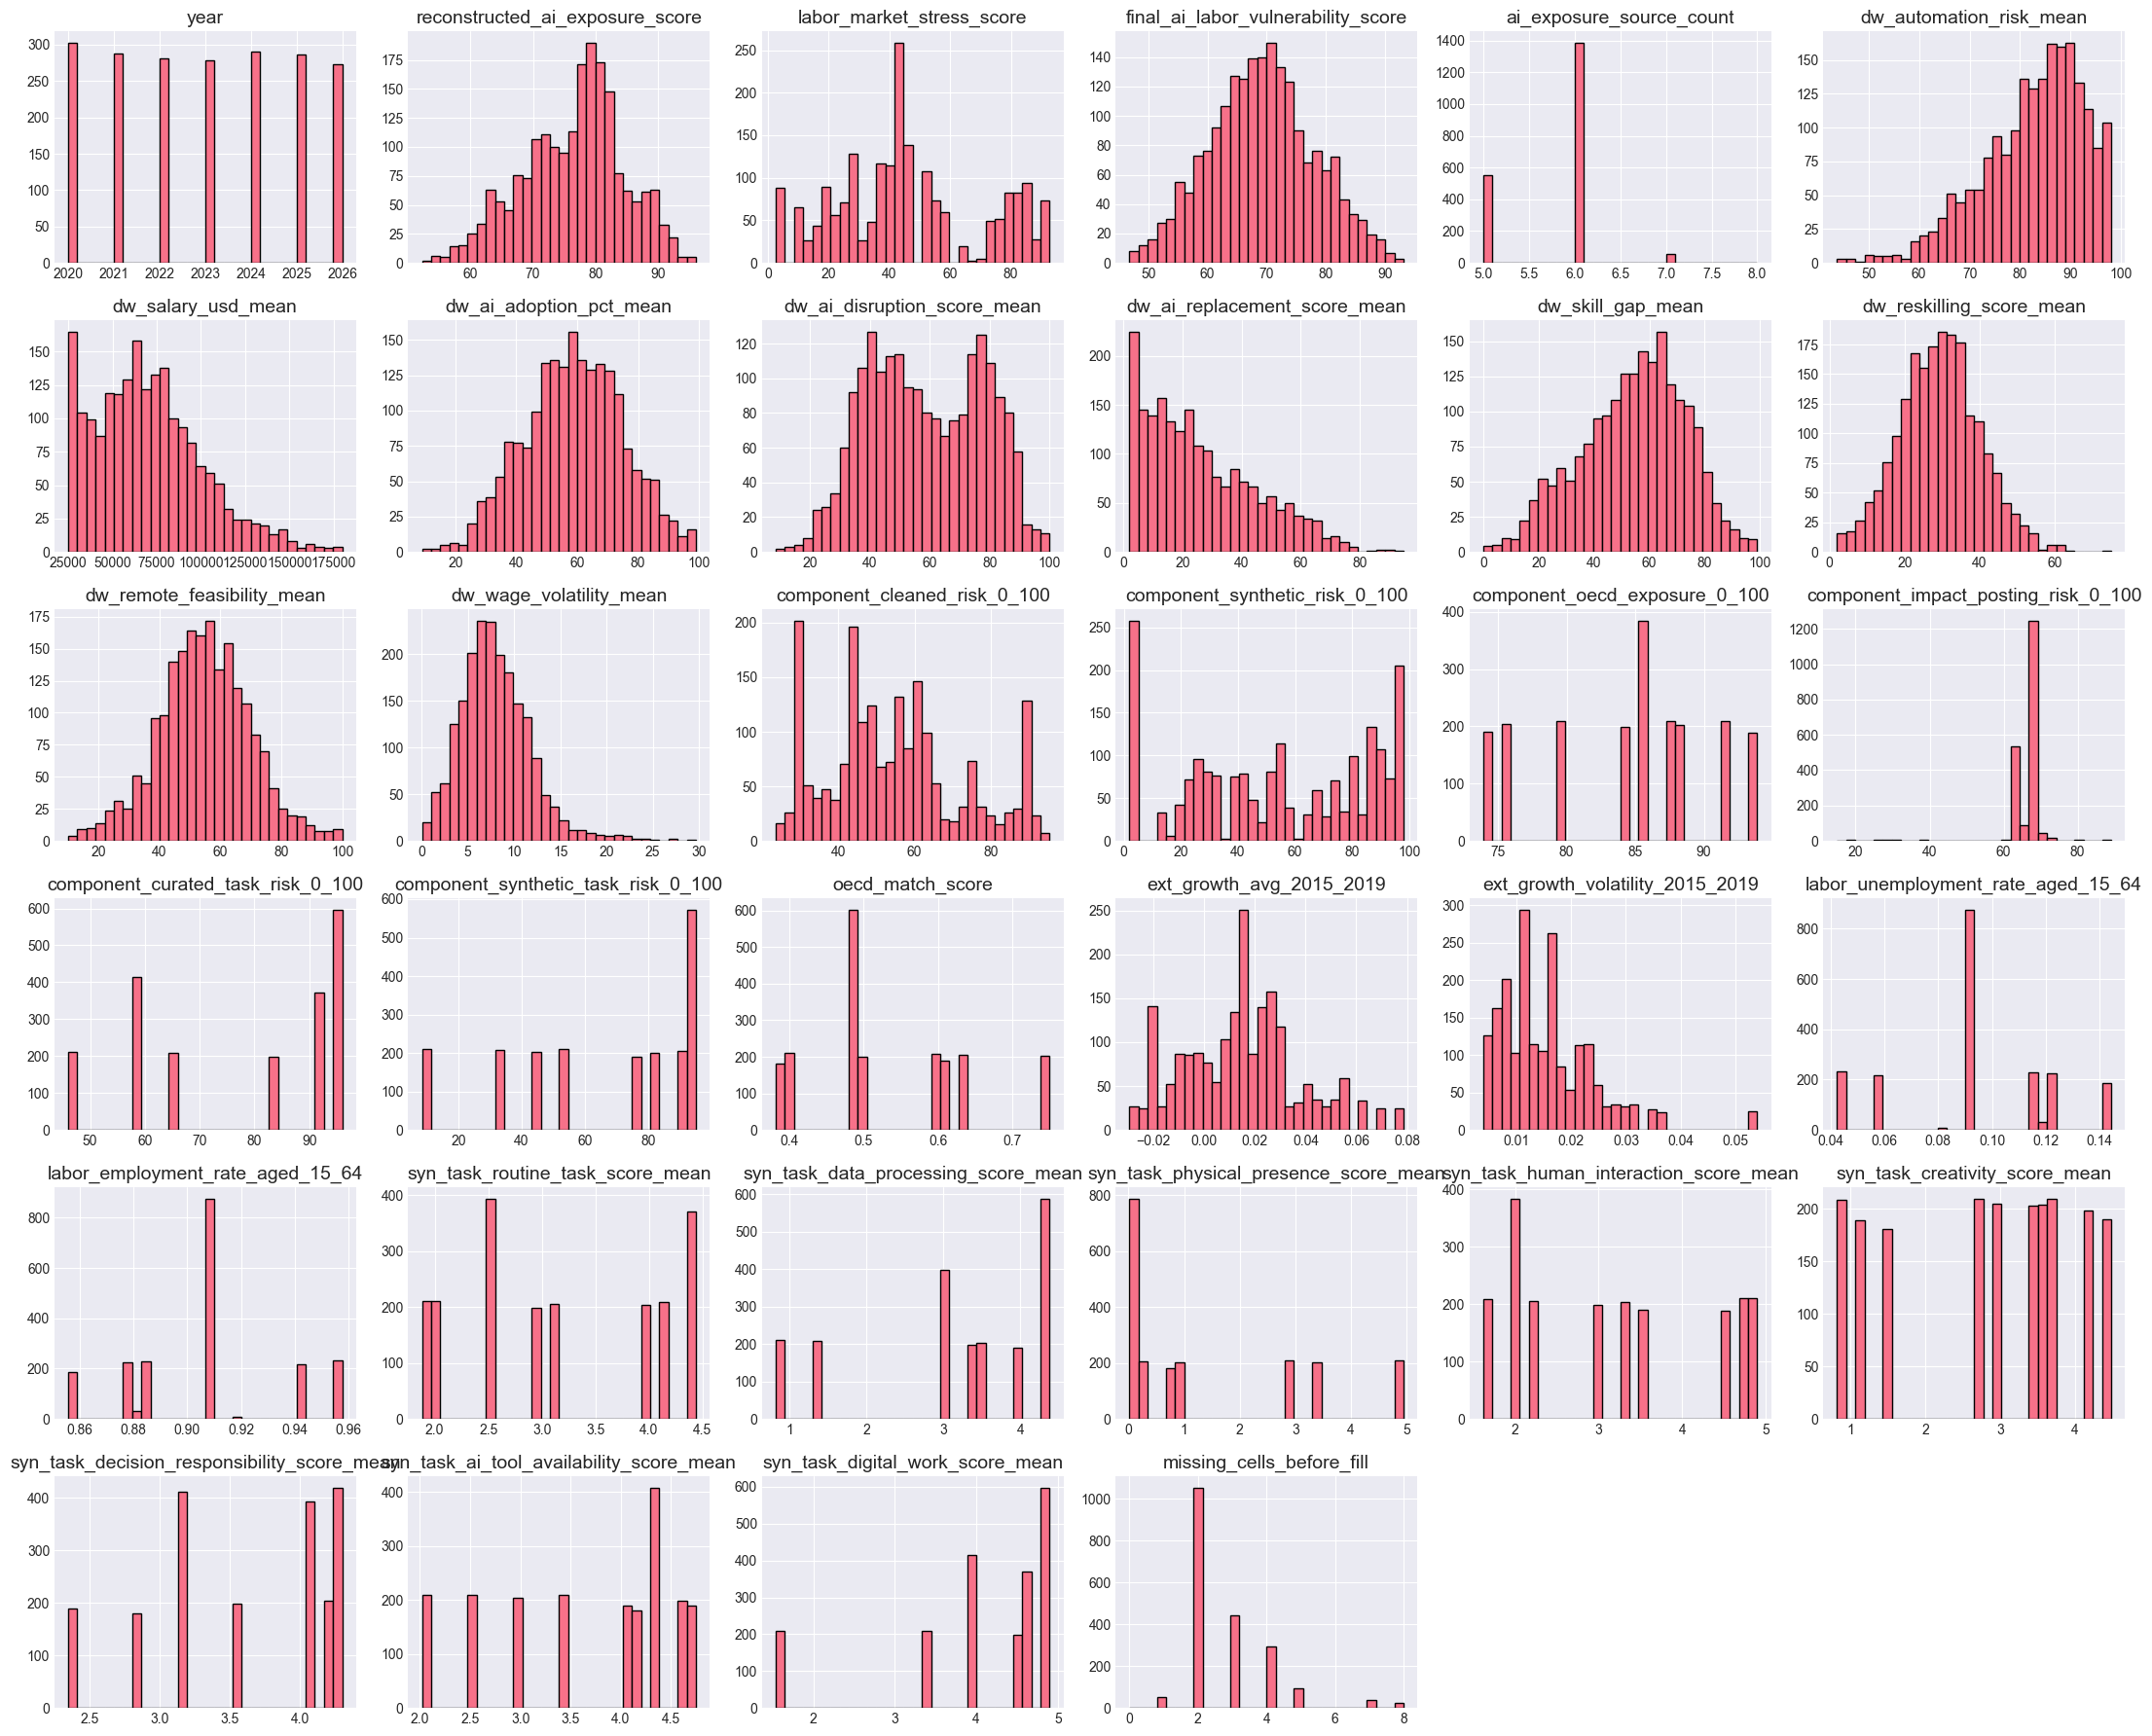

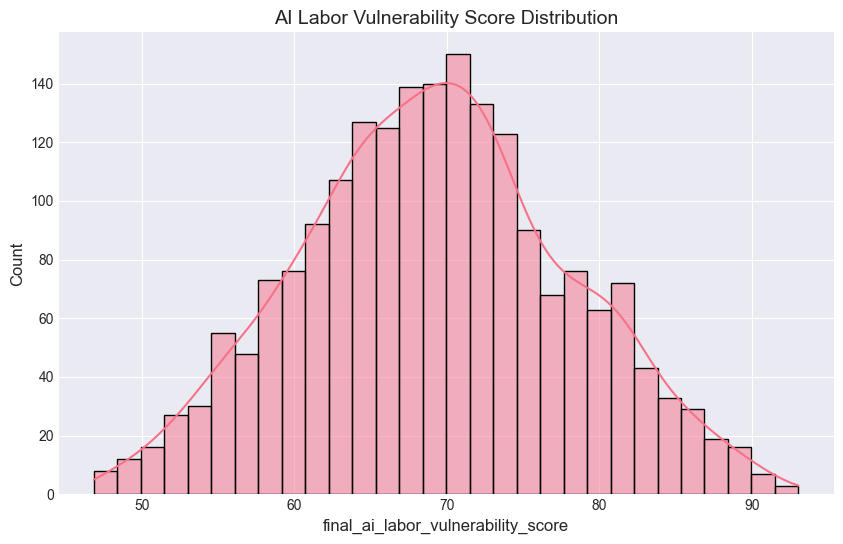

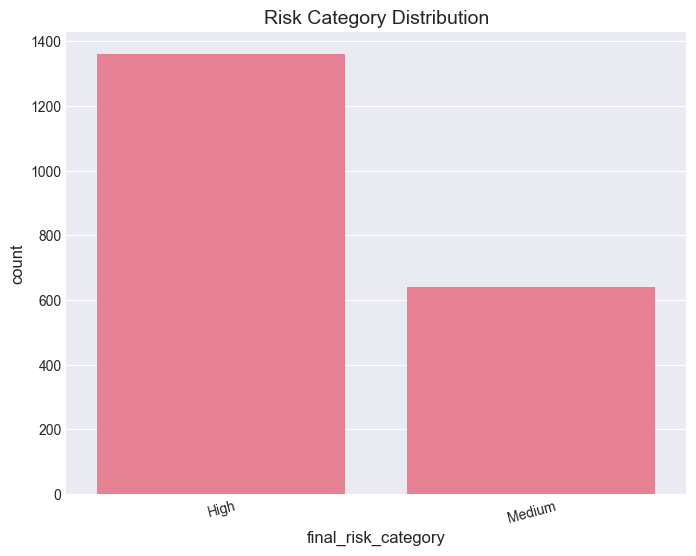

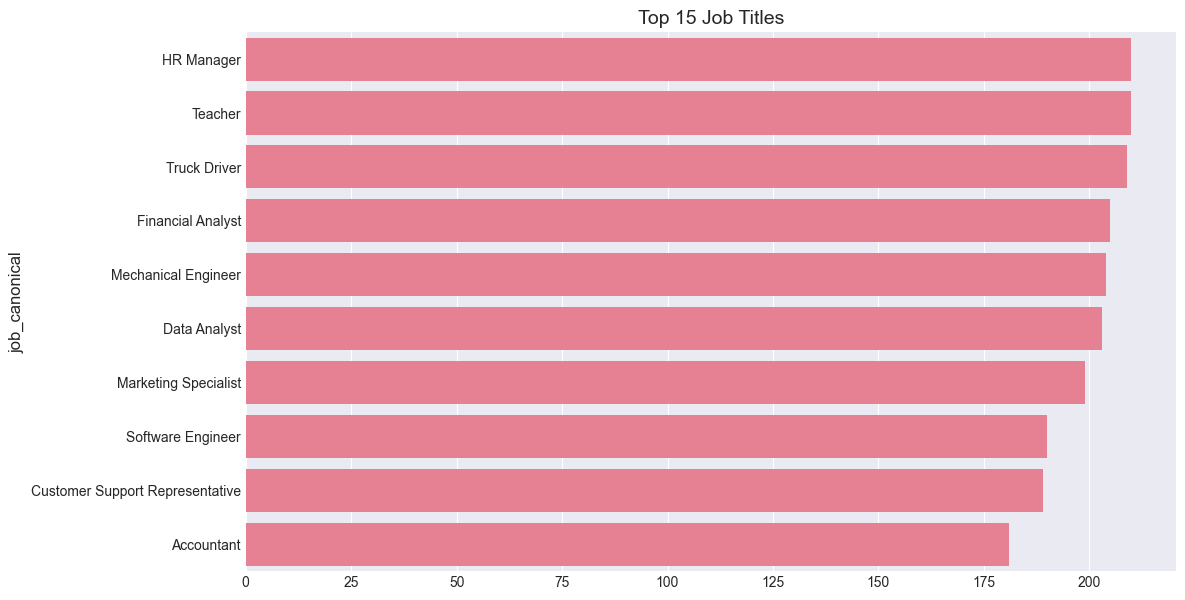

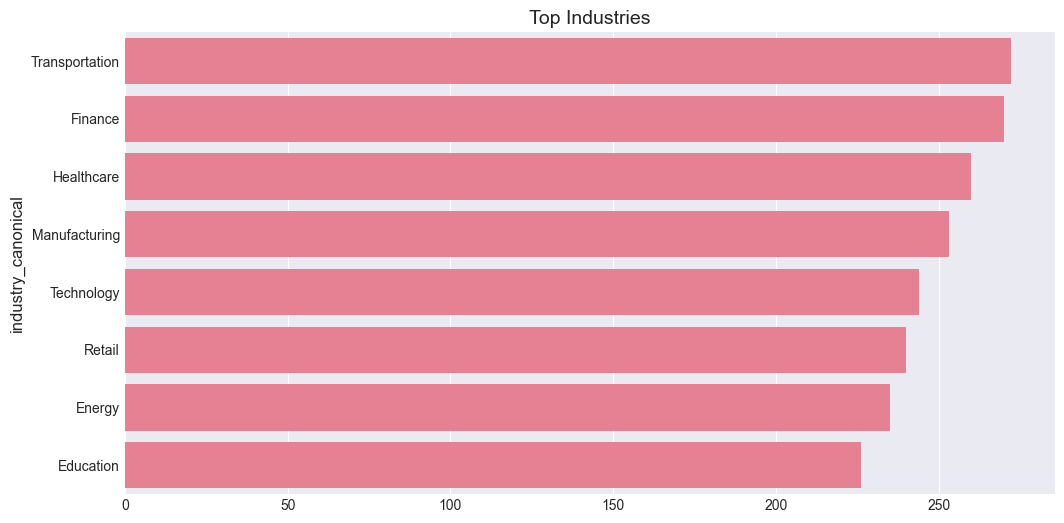

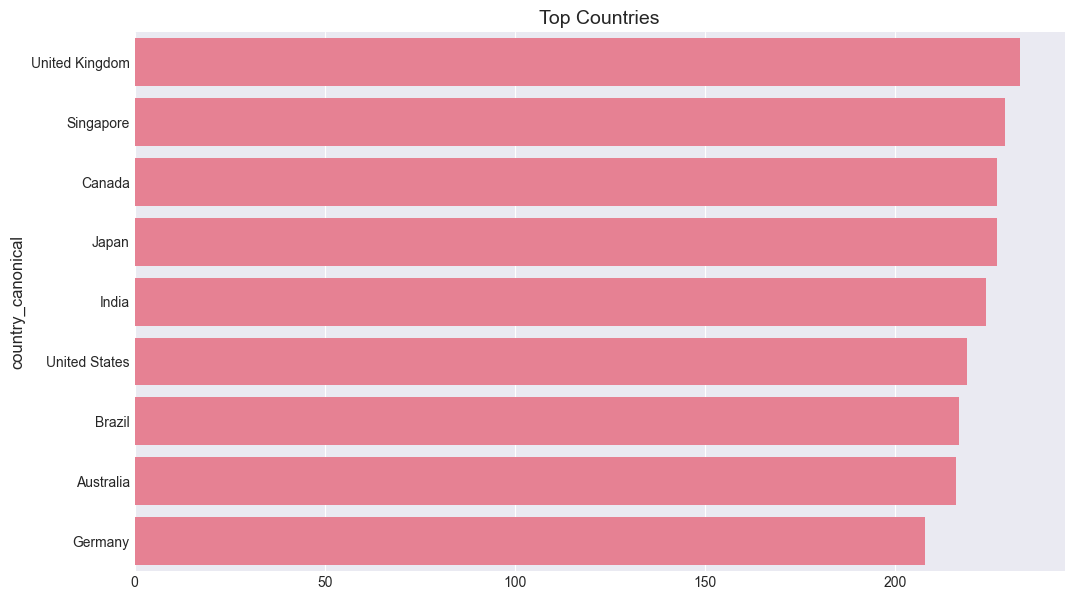

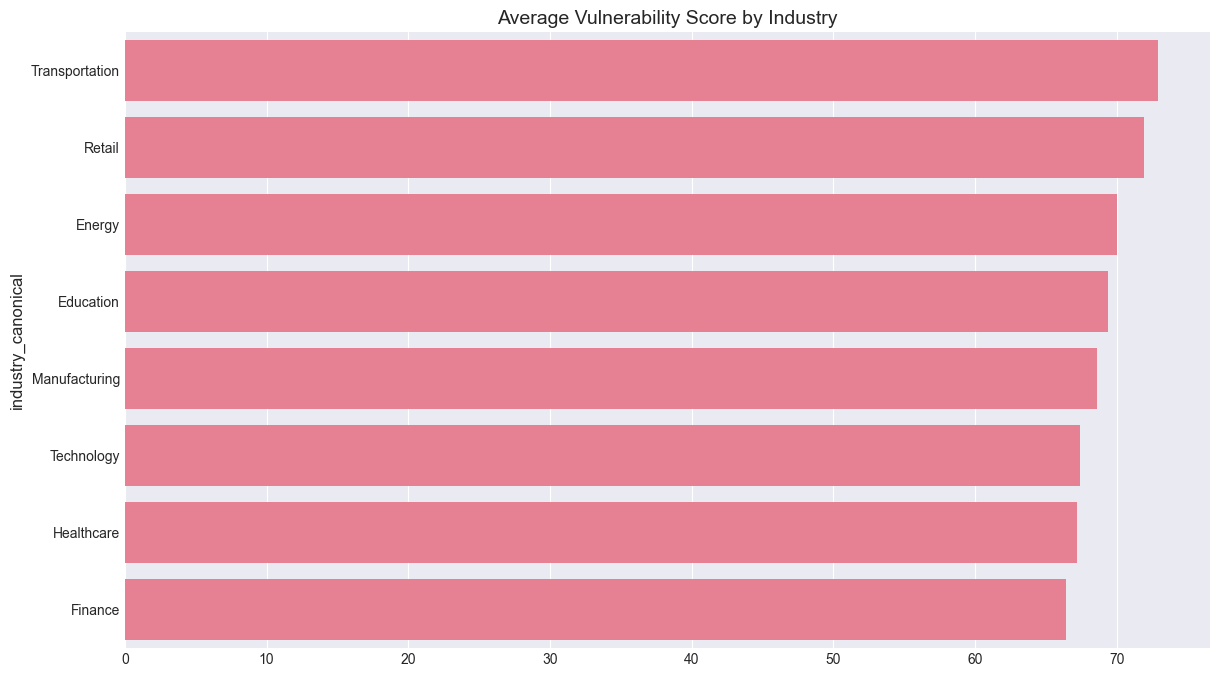

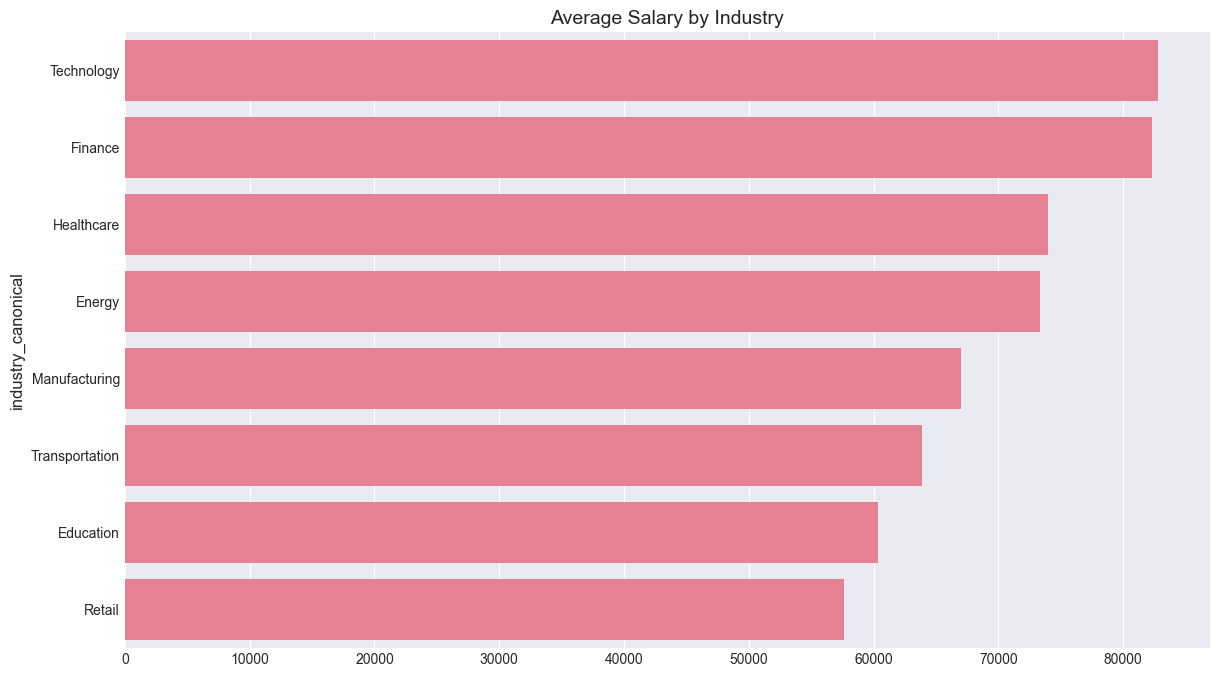

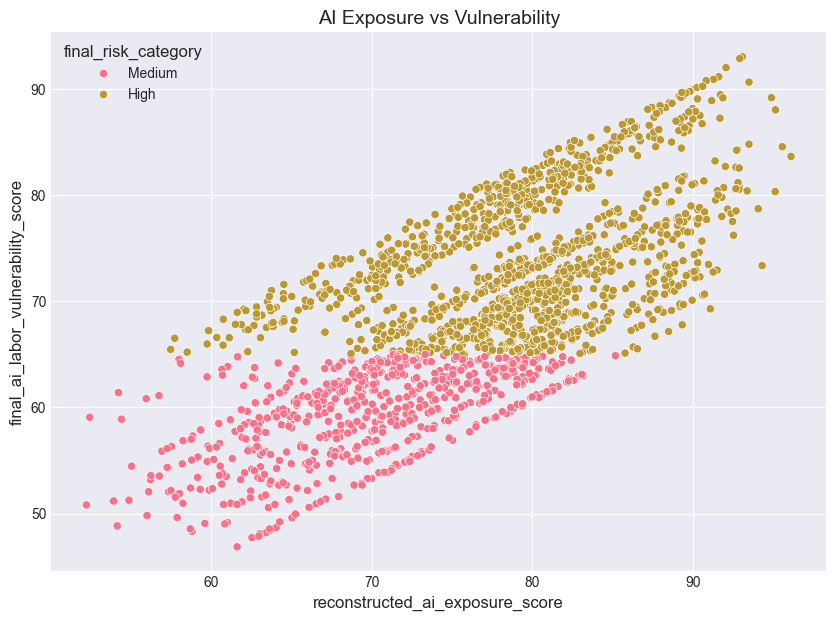

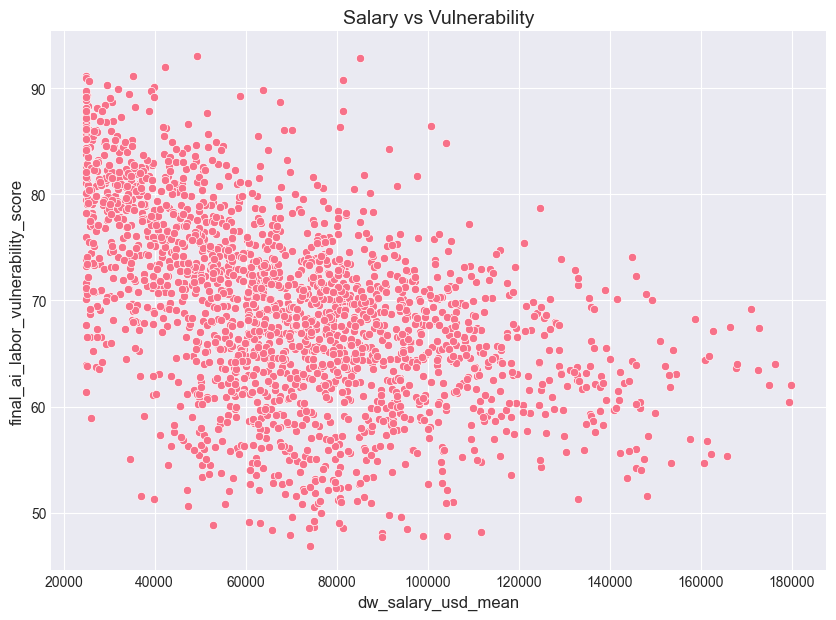

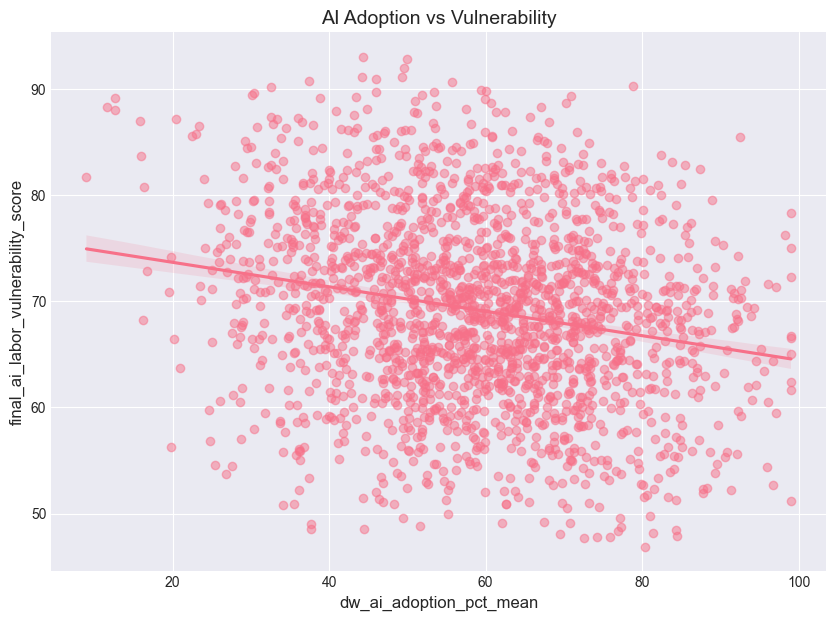

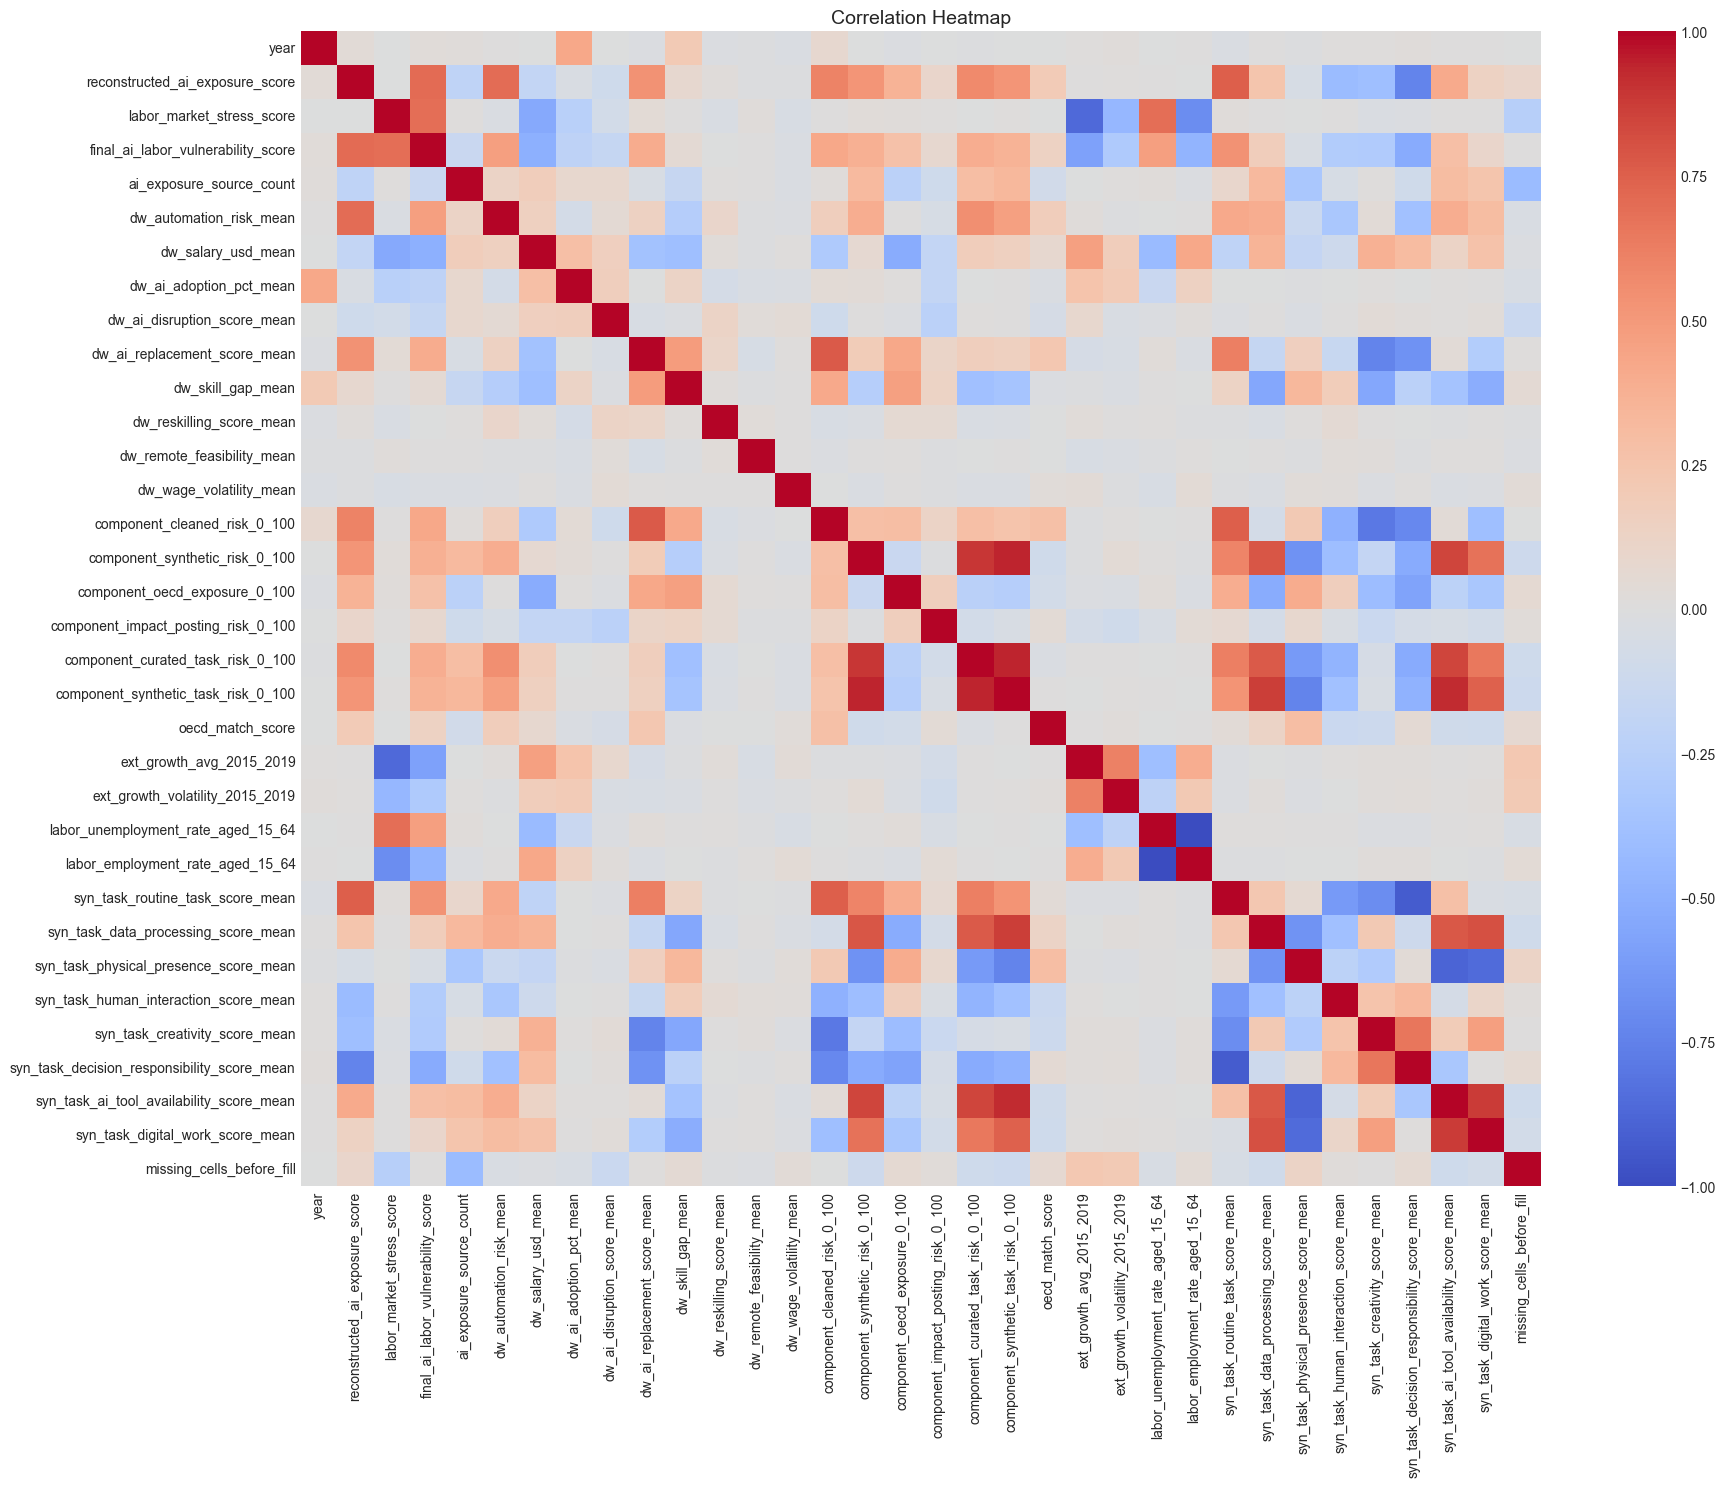

In [6]:
print("="*80)
print("NUMERICAL FEATURES DISTRIBUTION")
print("="*80)

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(22,18),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="final_ai_labor_vulnerability_score",
    kde=True,
    bins=30
)

plt.title("AI Labor Vulnerability Score Distribution")

plt.show()
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="final_risk_category",
    order=df["final_risk_category"].value_counts().index
)

plt.title("Risk Category Distribution")

plt.xticks(rotation=15)

plt.show()
plt.figure(figsize=(12,7))

top_jobs = (
    df["job_canonical"]
    .value_counts()
    .head(15)
)

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top 15 Job Titles")

plt.show()
plt.figure(figsize=(12,6))

industry = (
    df["industry_canonical"]
    .value_counts()
    .head(12)
)

sns.barplot(
    x=industry.values,
    y=industry.index
)

plt.title("Top Industries")

plt.show()
plt.figure(figsize=(12,7))

countries = (
    df["country_canonical"]
    .value_counts()
    .head(15)
)

sns.barplot(
    x=countries.values,
    y=countries.index
)

plt.title("Top Countries")

plt.show()
plt.figure(figsize=(14,8))

industry_risk = (
    df.groupby("industry_canonical")[
        "final_ai_labor_vulnerability_score"
    ]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=industry_risk.values,
    y=industry_risk.index
)

plt.title("Average Vulnerability Score by Industry")

plt.show()
plt.figure(figsize=(14,8))

salary = (
    df.groupby("industry_canonical")[
        "dw_salary_usd_mean"
    ]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=salary.values,
    y=salary.index
)

plt.title("Average Salary by Industry")

plt.show()
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="reconstructed_ai_exposure_score",
    y="final_ai_labor_vulnerability_score",
    hue="final_risk_category"
)

plt.title("AI Exposure vs Vulnerability")

plt.show()
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="dw_salary_usd_mean",
    y="final_ai_labor_vulnerability_score"
)

plt.title("Salary vs Vulnerability")

plt.show()
plt.figure(figsize=(10,7))

sns.regplot(
    data=df,
    x="dw_ai_adoption_pct_mean",
    y="final_ai_labor_vulnerability_score",
    scatter_kws={"alpha":0.5}
)

plt.title("AI Adoption vs Vulnerability")

plt.show()
plt.figure(figsize=(20,15))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

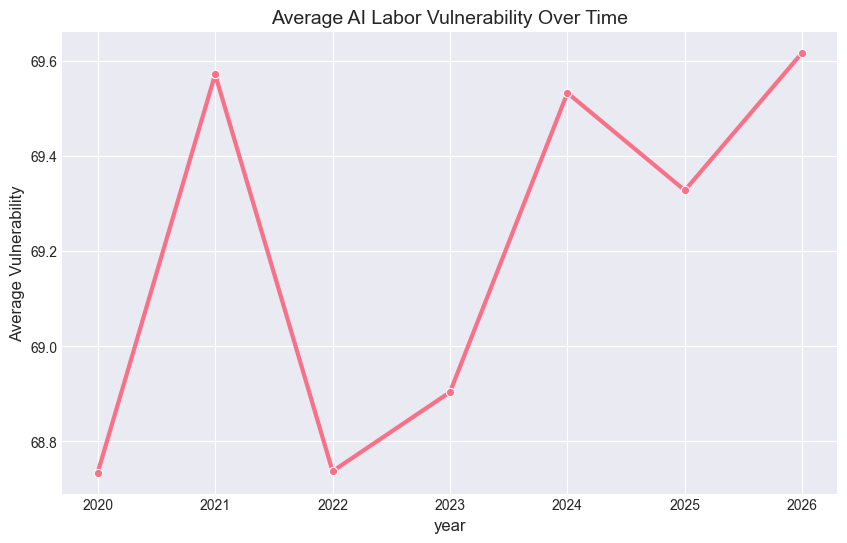

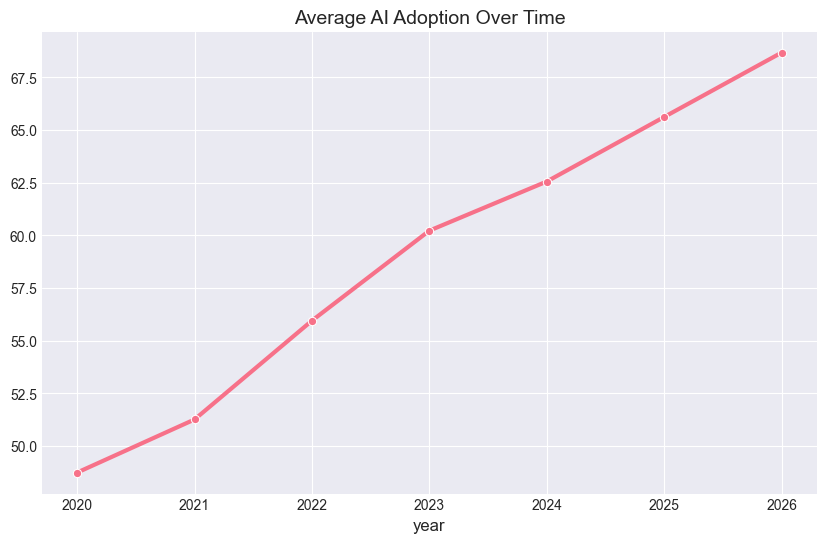

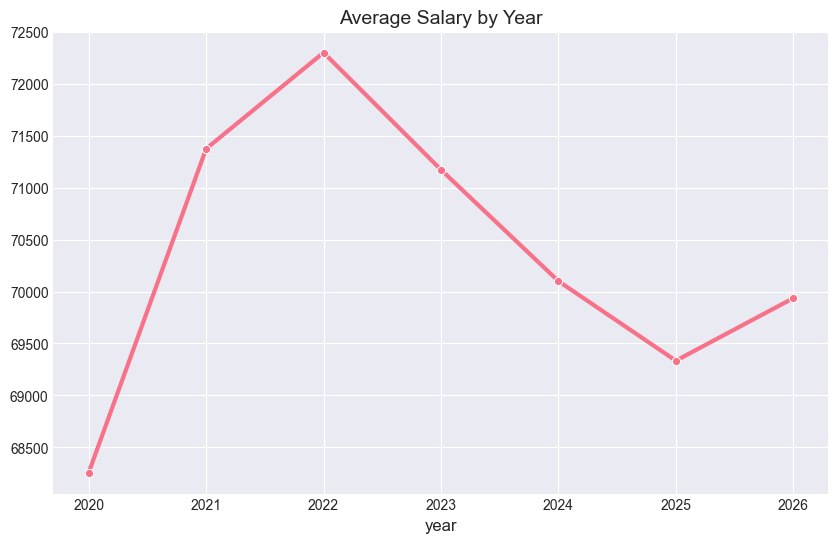

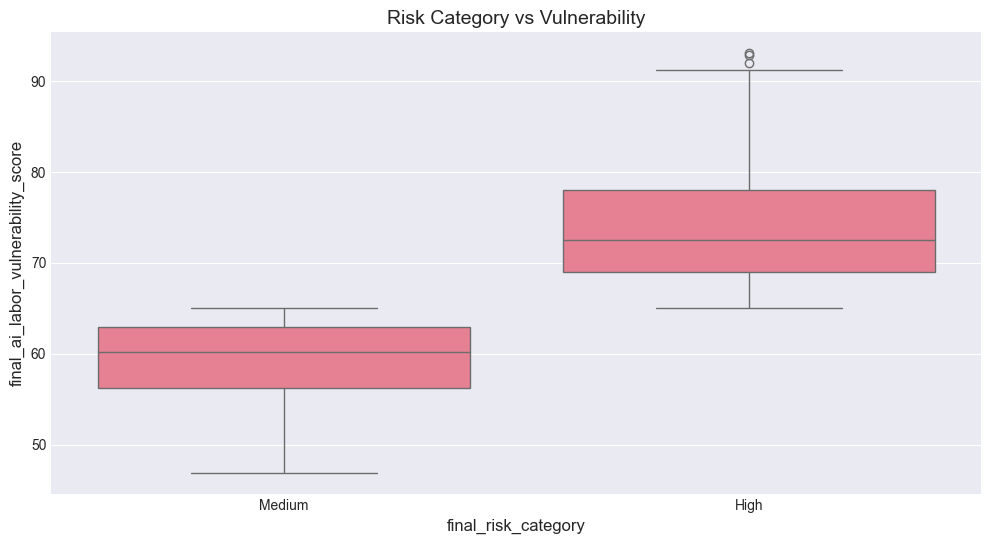

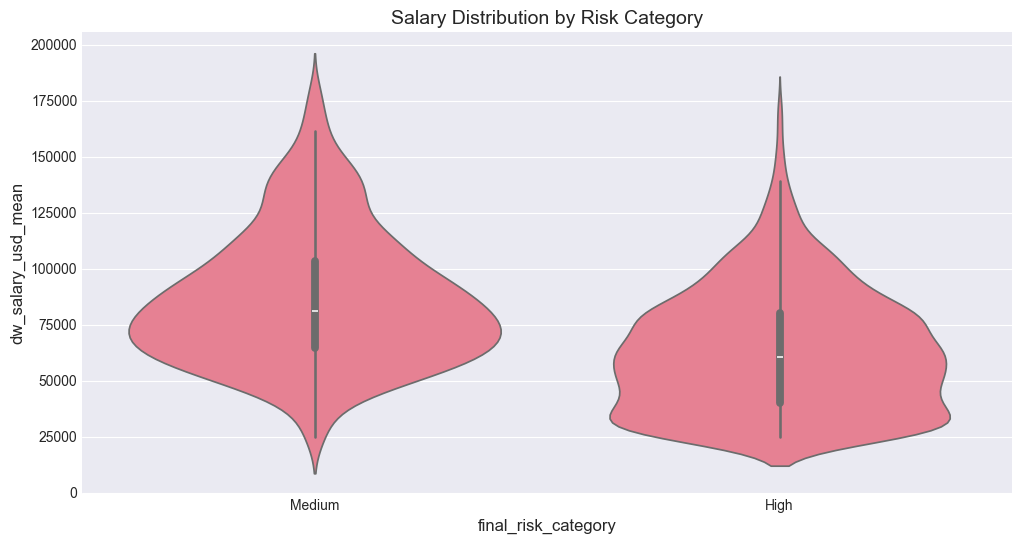

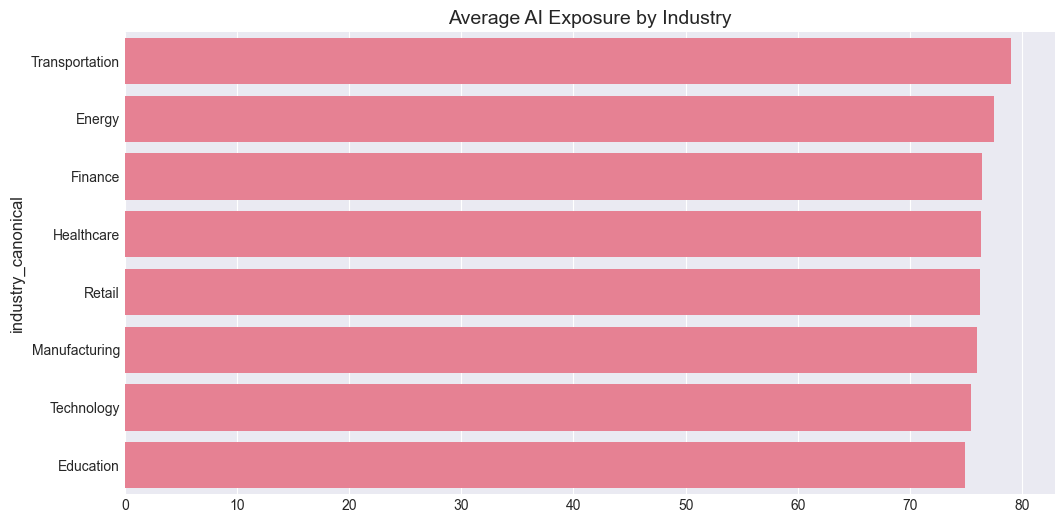

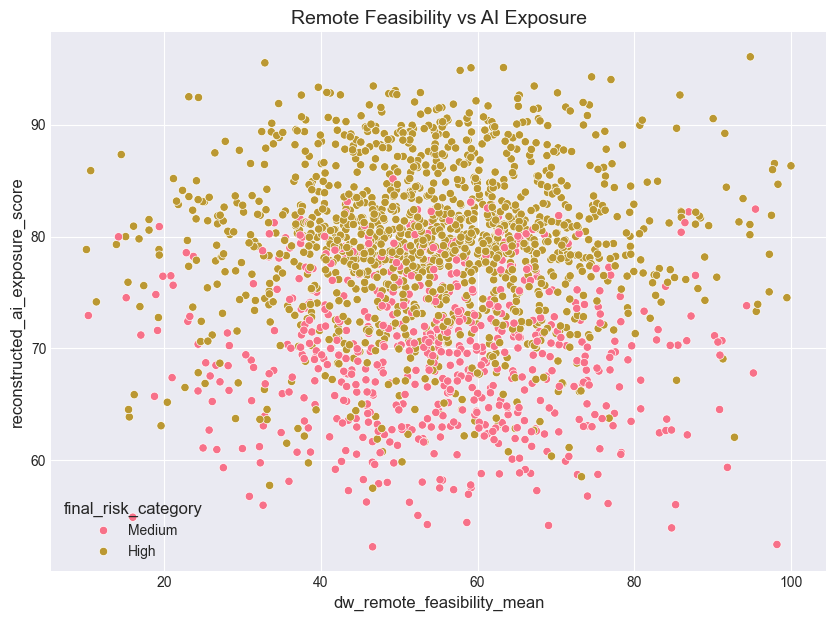

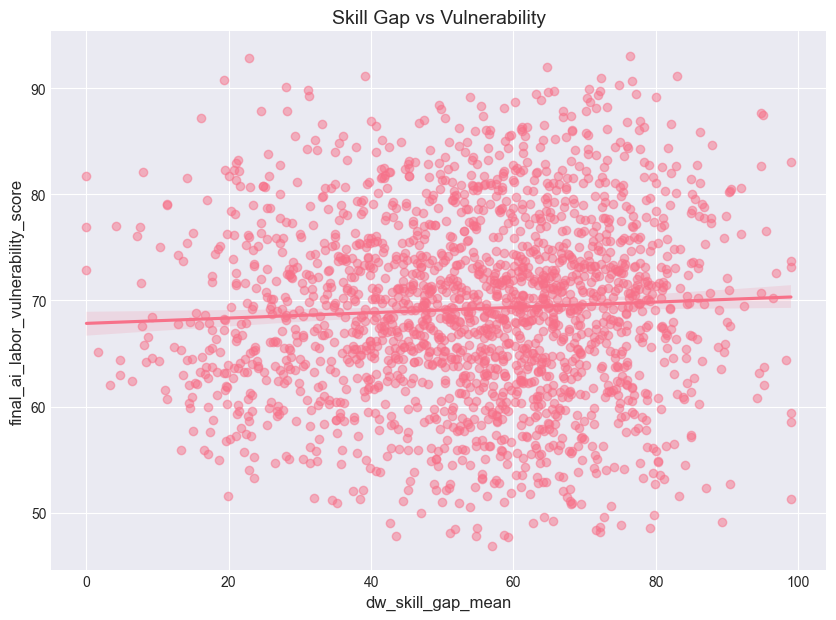

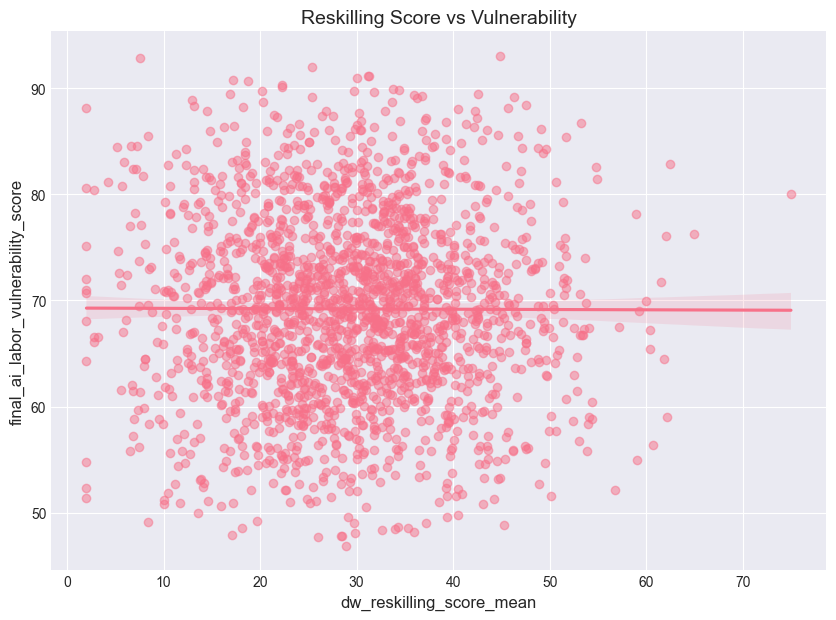

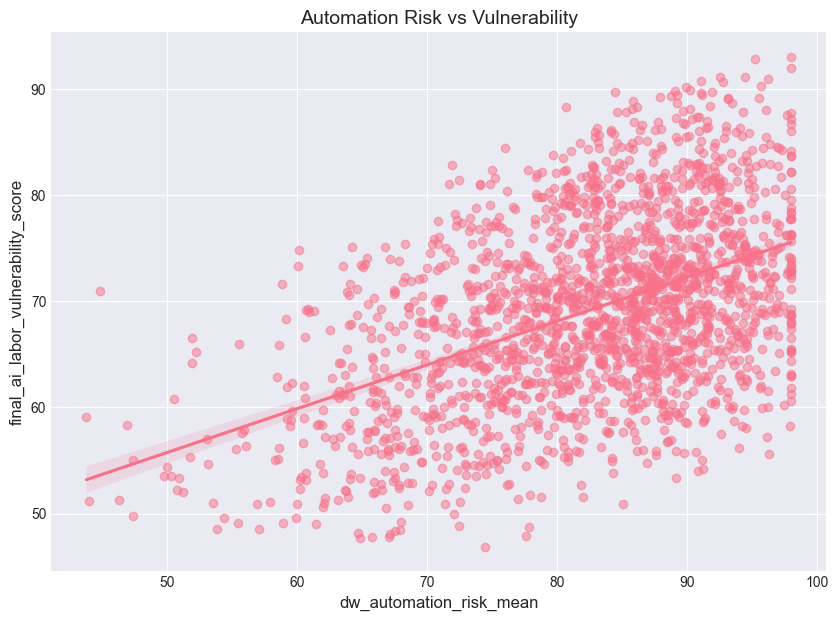

final_ai_labor_vulnerability_score             1.000000
reconstructed_ai_exposure_score                0.703509
labor_market_stress_score                      0.688284
syn_task_routine_task_score_mean               0.536518
labor_unemployment_rate_aged_15_64             0.475524
dw_automation_risk_mean                        0.469614
component_cleaned_risk_0_100                   0.428968
dw_ai_replacement_score_mean                   0.404838
component_curated_task_risk_0_100              0.396593
component_synthetic_risk_0_100                 0.380747
component_synthetic_task_risk_0_100            0.365820
syn_task_ai_tool_availability_score_mean       0.286675
component_oecd_exposure_0_100                  0.269380
syn_task_data_processing_score_mean            0.173991
oecd_match_score                               0.134374
syn_task_digital_work_score_mean               0.100482
component_impact_posting_risk_0_100            0.072579
dw_skill_gap_mean                              0

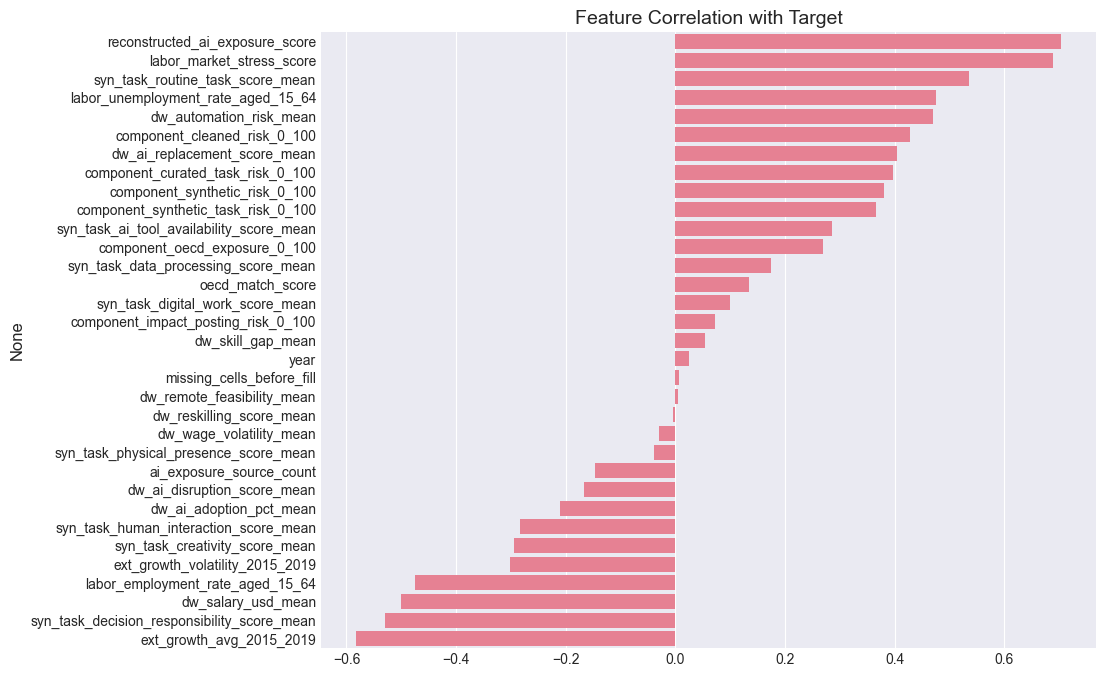

In [7]:
plt.figure(figsize=(10,6))

year_analysis = (
    df.groupby("year")[
        "final_ai_labor_vulnerability_score"
    ]
    .mean()
)

sns.lineplot(
    x=year_analysis.index,
    y=year_analysis.values,
    marker="o",
    linewidth=3
)

plt.title("Average AI Labor Vulnerability Over Time")

plt.ylabel("Average Vulnerability")

plt.show()
plt.figure(figsize=(10,6))

adoption = (
    df.groupby("year")[
        "dw_ai_adoption_pct_mean"
    ]
    .mean()
)

sns.lineplot(
    x=adoption.index,
    y=adoption.values,
    marker="o",
    linewidth=3
)

plt.title("Average AI Adoption Over Time")

plt.show()
plt.figure(figsize=(10,6))

salary = (
    df.groupby("year")[
        "dw_salary_usd_mean"
    ]
    .mean()
)

sns.lineplot(
    x=salary.index,
    y=salary.values,
    marker="o",
    linewidth=3
)

plt.title("Average Salary by Year")

plt.show()
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="final_risk_category",
    y="final_ai_labor_vulnerability_score"
)

plt.title("Risk Category vs Vulnerability")

plt.show()
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="final_risk_category",
    y="dw_salary_usd_mean"
)

plt.title("Salary Distribution by Risk Category")

plt.show()
top = (
    df.groupby("industry_canonical")
      ["reconstructed_ai_exposure_score"]
      .mean()
      .sort_values(ascending=False)
      .head(12)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Average AI Exposure by Industry")

plt.show()
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=df,

    x="dw_remote_feasibility_mean",

    y="reconstructed_ai_exposure_score",

    hue="final_risk_category"

)

plt.title("Remote Feasibility vs AI Exposure")

plt.show()
plt.figure(figsize=(10,7))

sns.regplot(

    data=df,

    x="dw_skill_gap_mean",

    y="final_ai_labor_vulnerability_score",

    scatter_kws={"alpha":0.5}

)

plt.title("Skill Gap vs Vulnerability")

plt.show()
plt.figure(figsize=(10,7))

sns.regplot(

    data=df,

    x="dw_reskilling_score_mean",

    y="final_ai_labor_vulnerability_score",

    scatter_kws={"alpha":0.5}

)

plt.title("Reskilling Score vs Vulnerability")

plt.show()
plt.figure(figsize=(10,7))

sns.regplot(

    data=df,

    x="dw_automation_risk_mean",

    y="final_ai_labor_vulnerability_score",

    scatter_kws={"alpha":0.5}

)

plt.title("Automation Risk vs Vulnerability")

plt.show()
corr = (
    df.corr(numeric_only=True)
    ["final_ai_labor_vulnerability_score"]
    .sort_values(ascending=False)
)

display(corr)
plt.figure(figsize=(10,8))

corr = corr.drop(
    "final_ai_labor_vulnerability_score"
)

sns.barplot(

    x=corr.values,

    y=corr.index

)

plt.title("Feature Correlation with Target")

plt.show()

## 6. Leakage-Safe Machine Learning Pipeline

This section prepares the data using:

- `ColumnTransformer`
- `SimpleImputer`
- `StandardScaler`
- `OneHotEncoder`
- `Pipeline`

Direct target-construction columns are removed to reduce data leakage.

In [8]:
# ============================================================================
# ⚙️ SECTION 6 - LEAKAGE-SAFE MACHINE LEARNING PIPELINE
# ============================================================================
#
# Objective:
#
# 1. Define the prediction target.
# 2. Remove target leakage and reconstruction metadata.
# 3. Detect numerical and categorical features.
# 4. Create automatic preprocessing pipelines.
# 5. Split the data into training and testing sets.
#
# ============================================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.base import clone


# ----------------------------------------------------------------------------
# STEP 1: Define the Target Variable
# ----------------------------------------------------------------------------

TARGET = "final_ai_labor_vulnerability_score"


if TARGET not in df.columns:

    raise KeyError(
        f"Target column '{TARGET}' is missing."
    )


# ----------------------------------------------------------------------------
# STEP 2: Remove Data-Leakage Columns
# ----------------------------------------------------------------------------
#
# The target appears to be constructed from AI exposure,
# labor-market stress, and component risk scores.
#
# Using those fields would produce unrealistically high model performance.
# ----------------------------------------------------------------------------

leakage_columns = [

    TARGET,

    "final_risk_category",

    "reconstructed_ai_exposure_score",

    "labor_market_stress_score",

    "component_cleaned_risk_0_100",

    "component_synthetic_risk_0_100",

    "component_oecd_exposure_0_100",

    "component_impact_posting_risk_0_100",

    "component_curated_task_risk_0_100",

    "component_synthetic_task_risk_0_100",

]


# ----------------------------------------------------------------------------
# STEP 3: Remove Metadata Columns
# ----------------------------------------------------------------------------
#
# These fields describe reconstruction sources or data quality.
# They are not suitable inputs for a real future prediction.
# ----------------------------------------------------------------------------

metadata_columns = [

    "reconstruction_confidence",

    "ai_exposure_source_count",

    "ai_exposure_source_list",

    "oecd_occ_code",

    "oecd_occupation_title",

    "missing_cells_before_fill",

    "row_fill_status",

]


columns_to_remove = [

    column

    for column in leakage_columns + metadata_columns

    if column in df.columns

]


# ----------------------------------------------------------------------------
# STEP 4: Separate Predictors and Target
# ----------------------------------------------------------------------------

X = df.drop(columns=columns_to_remove).copy()

y = df[TARGET].astype(float).copy()


# ----------------------------------------------------------------------------
# STEP 5: Detect Numerical and Categorical Features
# ----------------------------------------------------------------------------

numeric_features = (

    X.select_dtypes(include=np.number)

    .columns

    .tolist()

)


categorical_features = (

    X.select_dtypes(exclude=np.number)

    .columns

    .tolist()

)


# ----------------------------------------------------------------------------
# STEP 6: Numerical Preprocessing
# ----------------------------------------------------------------------------
#
# Missing numerical values are filled using the median.
# StandardScaler places numerical variables on comparable scales.
# ----------------------------------------------------------------------------

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        ),

    ]

)


# ----------------------------------------------------------------------------
# STEP 7: Categorical Preprocessing
# ----------------------------------------------------------------------------
#
# Missing categories are filled with the most frequent value.
# OneHotEncoder converts text into machine-readable columns.
# ----------------------------------------------------------------------------

categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        ),

    ]

)


# ----------------------------------------------------------------------------
# STEP 8: Combine Preprocessing Steps
# ----------------------------------------------------------------------------

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),

    ],

    remainder="drop"

)


# ----------------------------------------------------------------------------
# STEP 9: Create Training and Testing Sets
# ----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)


# ----------------------------------------------------------------------------
# STEP 10: Display the Final ML Dataset Summary
# ----------------------------------------------------------------------------

print("=" * 80)

print("✅ MACHINE LEARNING DATASET READY")

print("=" * 80)

print(f"Training Records     : {len(X_train):,}")

print(f"Testing Records      : {len(X_test):,}")

print(f"Input Features       : {X.shape[1]}")

print(f"Numerical Features   : {len(numeric_features)}")

print(f"Categorical Features : {len(categorical_features)}")

print(f"Excluded Columns     : {len(columns_to_remove)}")

✅ MACHINE LEARNING DATASET READY
Training Records     : 1,600
Testing Records      : 400
Input Features       : 26
Numerical Features   : 23
Categorical Features : 3
Excluded Columns     : 17


## 7. Model Training and Benchmark

Every regression algorithm uses the same preprocessing pipeline.
Models are compared using MAE, RMSE, and R².

✅ Linear Regression    | MAE: 2.0783 | RMSE: 2.9089 | R²: 0.8821
✅ Ridge Regression     | MAE: 2.0982 | RMSE: 2.9292 | R²: 0.8804
✅ Lasso Regression     | MAE: 2.1207 | RMSE: 2.9365 | R²: 0.8798
✅ Decision Tree        | MAE: 2.7421 | RMSE: 3.7823 | R²: 0.8006
✅ Random Forest        | MAE: 1.8678 | RMSE: 2.4543 | R²: 0.9161
✅ Extra Trees          | MAE: 1.2739 | RMSE: 1.7615 | R²: 0.9568
✅ Gradient Boosting    | MAE: 1.9093 | RMSE: 2.5120 | R²: 0.9121
✅ XGBoost              | MAE: 1.5496 | RMSE: 2.1122 | R²: 0.9378
✅ LightGBM             | MAE: 1.3413 | RMSE: 1.8413 | R²: 0.9527


,Model,MAE,RMSE,R2,Training Seconds
0,Extra Trees,1.273879,1.761513,0.956756,0.363031
1,LightGBM,1.341277,1.841326,0.952749,0.175365
2,XGBoost,1.549566,2.112199,0.937824,0.406383
3,Random Forest,1.867782,2.454286,0.916054,0.548478
4,Gradient Boosting,1.909293,2.511978,0.912061,0.654724
5,Linear Regression,2.078337,2.908933,0.882071,0.038101
6,Ridge Regression,2.098204,2.929198,0.880422,0.019616
7,Lasso Regression,2.120705,2.936520,0.879824,0.018914
8,Decision Tree,2.742074,3.782277,0.800630,0.039474


🏆 BEST BASELINE PIPELINE
Model : Extra Trees
MAE   : 1.2739
RMSE  : 1.7615
R²    : 0.9568


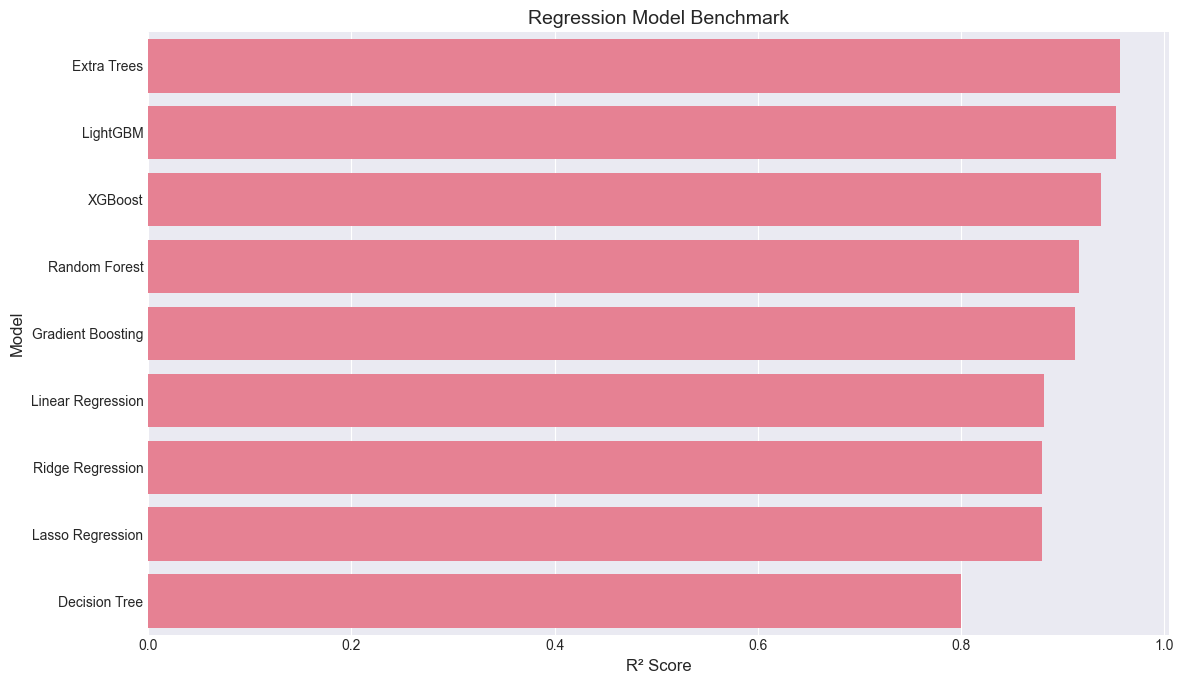

In [9]:
# ============================================================================
# 🤖 SECTION 7 - MODEL TRAINING AND BENCHMARK
# ============================================================================
#
# Objective:
#
# Train several regression algorithms using the same preprocessing workflow,
# compare their performance, and select the best Pipeline automatically.
#
# ============================================================================

import time

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ----------------------------------------------------------------------------
# STEP 1: Create the Model Dictionary
# ----------------------------------------------------------------------------

models = {

    "Linear Regression":

        LinearRegression(),

    "Ridge Regression":

        Ridge(alpha=1.0),

    "Lasso Regression":

        Lasso(
            alpha=0.05,
            max_iter=10000
        ),

    "Decision Tree":

        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":

        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":

        ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":

        GradientBoostingRegressor(
            random_state=42
        ),

}


# ----------------------------------------------------------------------------
# STEP 2: Add Optional Advanced Models
# ----------------------------------------------------------------------------

if globals().get("HAS_XGB", False):

    models["XGBoost"] = xgb.XGBRegressor(

        objective="reg:squarederror",

        n_estimators=200,

        random_state=42,

        n_jobs=-1

    )


if globals().get("HAS_LGB", False):

    models["LightGBM"] = lgb.LGBMRegressor(

        n_estimators=200,

        random_state=42,

        n_jobs=-1,

        verbosity=-1

    )


# ----------------------------------------------------------------------------
# STEP 3: Train All Models Inside Pipelines
# ----------------------------------------------------------------------------

benchmark_results = []

trained_pipelines = {}


for model_name, model in models.items():

    start_time = time.perf_counter()


    # Create a fresh independent preprocessor for every model.
    model_pipeline = Pipeline(

        steps=[

            (
                "preprocessor",
                clone(preprocessor)
            ),

            (
                "model",
                model
            ),

        ]

    )


    # Train the complete preprocessing + model workflow.
    model_pipeline.fit(

        X_train,

        y_train

    )


    # Generate predictions on unseen testing data.
    predictions = model_pipeline.predict(

        X_test

    )


    # Calculate regression evaluation metrics.
    mae = mean_absolute_error(

        y_test,

        predictions

    )


    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            predictions

        )

    )


    r2 = r2_score(

        y_test,

        predictions

    )


    elapsed_time = time.perf_counter() - start_time


    trained_pipelines[model_name] = model_pipeline


    benchmark_results.append({

        "Model": model_name,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2,

        "Training Seconds": elapsed_time

    })


    print(

        f"✅ {model_name:<20} | "

        f"MAE: {mae:.4f} | "

        f"RMSE: {rmse:.4f} | "

        f"R²: {r2:.4f}"

    )


# ----------------------------------------------------------------------------
# STEP 4: Rank the Models
# ----------------------------------------------------------------------------

results_df = (

    pd.DataFrame(benchmark_results)

    .sort_values(

        ["R2", "RMSE"],

        ascending=[False, True]

    )

    .reset_index(drop=True)

)


display(results_df)


# ----------------------------------------------------------------------------
# STEP 5: Select the Best Complete Pipeline
# ----------------------------------------------------------------------------

best_model_name = results_df.loc[0, "Model"]

best_pipeline = trained_pipelines[best_model_name]


best_predictions = best_pipeline.predict(

    X_test

)


best_mae = mean_absolute_error(

    y_test,

    best_predictions

)


best_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        best_predictions

    )

)


best_r2 = r2_score(

    y_test,

    best_predictions

)


print("=" * 80)

print("🏆 BEST BASELINE PIPELINE")

print("=" * 80)

print(f"Model : {best_model_name}")

print(f"MAE   : {best_mae:.4f}")

print(f"RMSE  : {best_rmse:.4f}")

print(f"R²    : {best_r2:.4f}")


# ----------------------------------------------------------------------------
# STEP 6: Visualize the Benchmark
# ----------------------------------------------------------------------------

plt.figure(figsize=(12, 7))

sns.barplot(

    data=results_df,

    x="R2",

    y="Model"

)

plt.title("Regression Model Benchmark")

plt.xlabel("R² Score")

plt.ylabel("Model")

plt.tight_layout()

plt.show()

## 8. Cross-Validation, Optimization and Final Evaluation

The best baseline Pipeline is validated across multiple folds and tuned using
model-specific hyperparameters. The optimized model is retained only when its
holdout performance is at least as good as the baseline.

BASELINE CROSS-VALIDATION
Fold Scores : [0.9574 0.9601 0.9665 0.9629 0.9442]
Mean R²     : 0.9582
Std R²      : 0.0076
BEST HYPERPARAMETERS
{'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': None}
Tuning CV R²: 0.9450


,Version,MAE,RMSE,R2
0,Best Baseline,1.273879,1.761513,0.956756
1,Tuned Candidate,1.280273,1.751709,0.957236
2,Selected Final Pipeline,1.280273,1.751709,0.957236


🏆 FINAL PIPELINE PERFORMANCE
Model   : Extra Trees - Optimized
MAE     : 1.2803
RMSE    : 1.7517
R²      : 0.9572
CV R²   : 0.9584
CV Std  : 0.0072


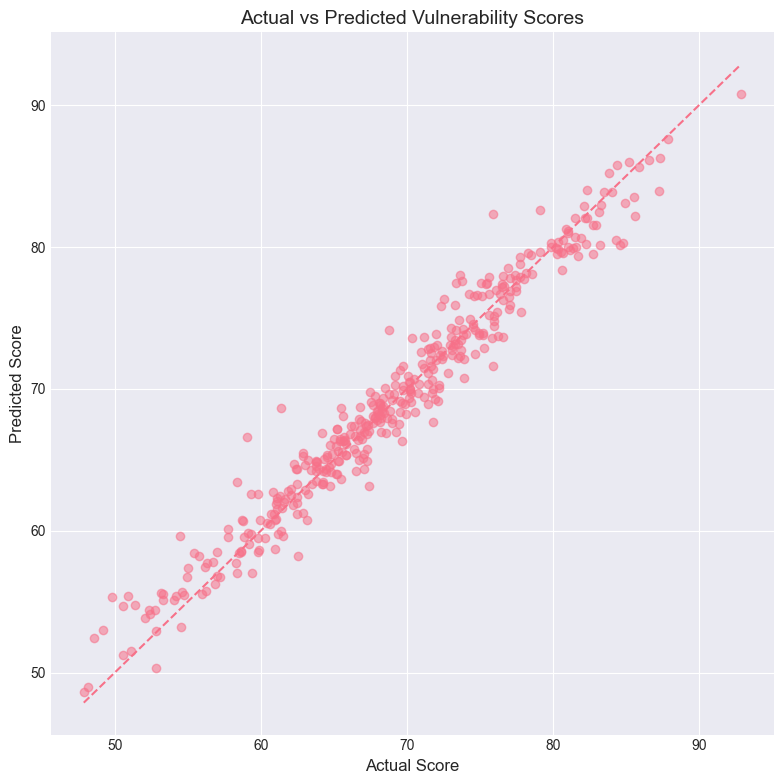

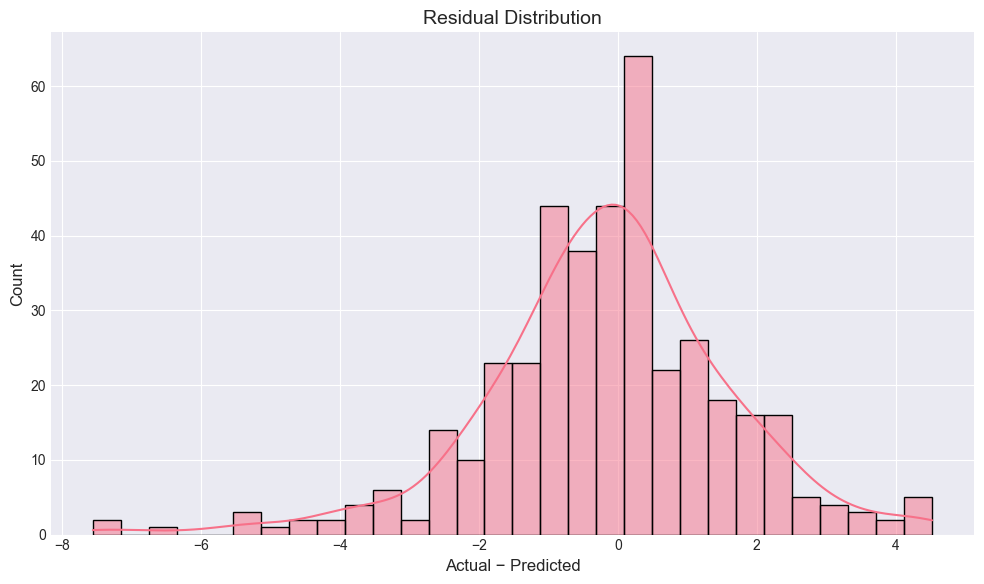

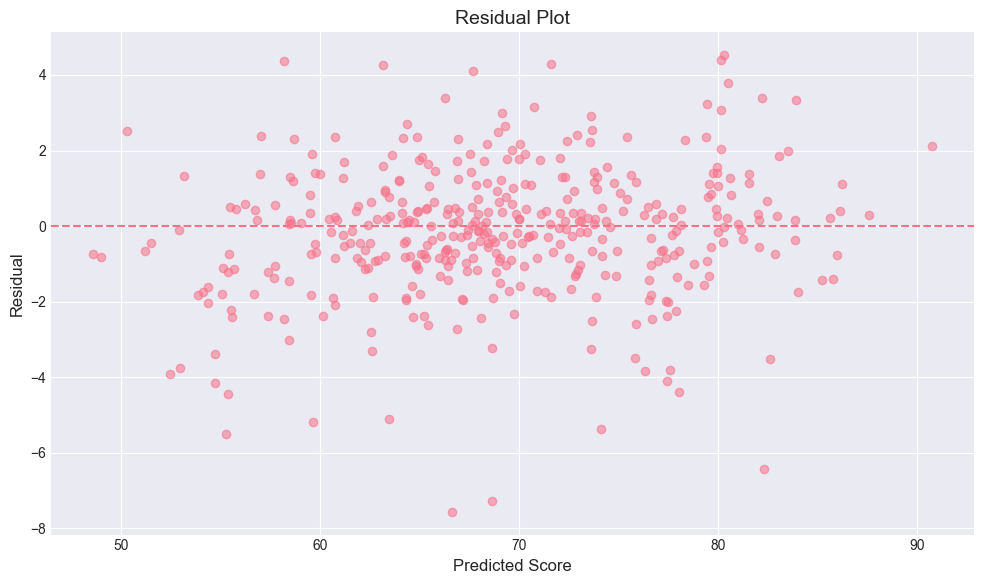

,Feature,Importance
0,ext_growth_avg_2015_2019,0.168486
1,syn_task_routine_task_score_mean,0.143948
2,syn_task_decision_responsibility_score_mean,0.077905
3,labor_unemployment_rate_aged_15_64,0.075517
4,dw_salary_usd_mean,0.074155
5,labor_employment_rate_aged_15_64,0.059823
6,dw_automation_risk_mean,0.053400
7,industry_canonical_Transportation,0.047498
8,syn_task_human_interaction_score_mean,0.034876
9,ext_growth_volatility_2015_2019,0.028224


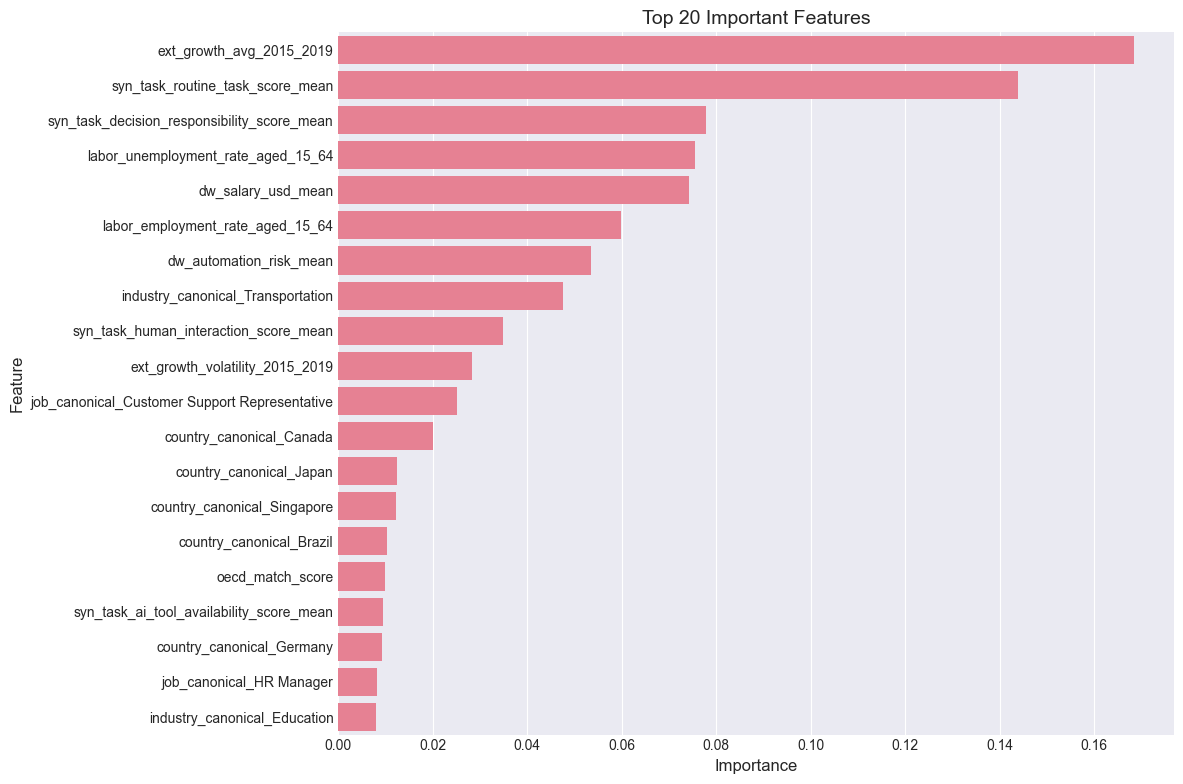

In [10]:
# ============================================================================
# 🚀 SECTION 8 - MODEL OPTIMIZATION AND FINAL EVALUATION
# ============================================================================

from sklearn.model_selection import (
    KFold,
    cross_val_score,
    RandomizedSearchCV,
    learning_curve
)

from sklearn.inspection import permutation_importance


# ----------------------------------------------------------------------------
# STEP 1: Cross-Validate the Best Baseline Pipeline
# ----------------------------------------------------------------------------

cv_strategy = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


baseline_cv_scores = cross_val_score(

    best_pipeline,

    X,

    y,

    cv=cv_strategy,

    scoring="r2",

    n_jobs=-1

)


print("=" * 80)

print("BASELINE CROSS-VALIDATION")

print("=" * 80)

print(f"Fold Scores : {np.round(baseline_cv_scores, 4)}")

print(f"Mean R²     : {baseline_cv_scores.mean():.4f}")

print(f"Std R²      : {baseline_cv_scores.std():.4f}")


# ----------------------------------------------------------------------------
# STEP 2: Define Model-Specific Hyperparameters
# ----------------------------------------------------------------------------

search_spaces = {

    "Ridge Regression": {

        "model__alpha":

            np.logspace(-3, 3, 30)

    },

    "Lasso Regression": {

        "model__alpha":

            np.logspace(-4, 1, 30)

    },

    "Decision Tree": {

        "model__max_depth":

            [None, 5, 10, 15, 20, 30],

        "model__min_samples_split":

            [2, 5, 10, 20],

        "model__min_samples_leaf":

            [1, 2, 4, 8]

    },

    "Random Forest": {

        "model__n_estimators":

            [100, 200, 300, 400],

        "model__max_depth":

            [None, 8, 15, 25],

        "model__min_samples_split":

            [2, 5, 10],

        "model__min_samples_leaf":

            [1, 2, 4],

        "model__max_features":

            ["sqrt", 0.7, 1.0]

    },

    "Extra Trees": {

        "model__n_estimators":

            [100, 200, 300, 400],

        "model__max_depth":

            [None, 8, 15, 25],

        "model__min_samples_split":

            [2, 5, 10],

        "model__min_samples_leaf":

            [1, 2, 4],

        "model__max_features":

            ["sqrt", 0.7, 1.0]

    },

    "Gradient Boosting": {

        "model__n_estimators":

            [75, 100, 150, 250],

        "model__learning_rate":

            [0.02, 0.05, 0.1, 0.2],

        "model__max_depth":

            [2, 3, 4, 5],

        "model__subsample":

            [0.7, 0.85, 1.0]

    }

}


selected_search_space = search_spaces.get(

    best_model_name

)


# ----------------------------------------------------------------------------
# STEP 3: Tune the Best Model
# ----------------------------------------------------------------------------

if selected_search_space is not None:

    search = RandomizedSearchCV(

        estimator=best_pipeline,

        param_distributions=selected_search_space,

        n_iter=10,

        scoring="r2",

        cv=3,

        random_state=42,

        n_jobs=-1,

        refit=True

    )


    search.fit(

        X_train,

        y_train

    )


    optimized_pipeline = search.best_estimator_


    print("=" * 80)

    print("BEST HYPERPARAMETERS")

    print("=" * 80)

    print(search.best_params_)

    print(f"Tuning CV R²: {search.best_score_:.4f}")


else:

    search = None

    optimized_pipeline = best_pipeline

    print(

        "No tuning space was required for the selected model."

    )


# ----------------------------------------------------------------------------
# STEP 4: Compare Baseline and Optimized Pipelines
# ----------------------------------------------------------------------------

optimized_predictions = optimized_pipeline.predict(

    X_test

)


optimized_mae = mean_absolute_error(

    y_test,

    optimized_predictions

)


optimized_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        optimized_predictions

    )

)


optimized_r2 = r2_score(

    y_test,

    optimized_predictions

)


# Keep tuning only when it does not reduce holdout performance.
if optimized_r2 >= best_r2:

    final_pipeline = optimized_pipeline

    final_predictions = optimized_predictions

    final_model_name = f"{best_model_name} - Optimized"

else:

    final_pipeline = best_pipeline

    final_predictions = best_predictions

    final_model_name = f"{best_model_name} - Baseline Retained"


final_mae = mean_absolute_error(

    y_test,

    final_predictions

)


final_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        final_predictions

    )

)


final_r2 = r2_score(

    y_test,

    final_predictions

)


final_cv_scores = cross_val_score(

    final_pipeline,

    X,

    y,

    cv=cv_strategy,

    scoring="r2",

    n_jobs=-1

)


model_version_comparison = pd.DataFrame({

    "Version": [

        "Best Baseline",

        "Tuned Candidate",

        "Selected Final Pipeline"

    ],

    "MAE": [

        best_mae,

        optimized_mae,

        final_mae

    ],

    "RMSE": [

        best_rmse,

        optimized_rmse,

        final_rmse

    ],

    "R2": [

        best_r2,

        optimized_r2,

        final_r2

    ]

})


display(model_version_comparison)


print("=" * 80)

print("🏆 FINAL PIPELINE PERFORMANCE")

print("=" * 80)

print(f"Model   : {final_model_name}")

print(f"MAE     : {final_mae:.4f}")

print(f"RMSE    : {final_rmse:.4f}")

print(f"R²      : {final_r2:.4f}")

print(f"CV R²   : {final_cv_scores.mean():.4f}")

print(f"CV Std  : {final_cv_scores.std():.4f}")


# ----------------------------------------------------------------------------
# STEP 5: Actual vs Predicted Values
# ----------------------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.scatter(

    y_test,

    final_predictions,

    alpha=0.55

)


minimum_value = min(

    y_test.min(),

    final_predictions.min()

)


maximum_value = max(

    y_test.max(),

    final_predictions.max()

)


plt.plot(

    [minimum_value, maximum_value],

    [minimum_value, maximum_value],

    linestyle="--"

)

plt.title("Actual vs Predicted Vulnerability Scores")

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.tight_layout()

plt.show()


# ----------------------------------------------------------------------------
# STEP 6: Residual Analysis
# ----------------------------------------------------------------------------

residuals = (

    y_test.to_numpy()

    - final_predictions

)


plt.figure(figsize=(10, 6))

sns.histplot(

    residuals,

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.xlabel("Actual − Predicted")

plt.tight_layout()

plt.show()


plt.figure(figsize=(10, 6))

plt.scatter(

    final_predictions,

    residuals,

    alpha=0.55

)

plt.axhline(

    0,

    linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Predicted Score")

plt.ylabel("Residual")

plt.tight_layout()

plt.show()


# ----------------------------------------------------------------------------
# STEP 7: Feature Importance
# ----------------------------------------------------------------------------

fitted_preprocessor = (

    final_pipeline

    .named_steps["preprocessor"]

)


fitted_estimator = (

    final_pipeline

    .named_steps["model"]

)


try:

    transformed_feature_names = (

        fitted_preprocessor

        .get_feature_names_out()

    )


    transformed_feature_names = [

        name

        .replace("numeric__", "")

        .replace("categorical__", "")

        for name in transformed_feature_names

    ]

except Exception:

    transformed_feature_names = None


if hasattr(

    fitted_estimator,

    "feature_importances_"

):

    importance_values = np.asarray(

        fitted_estimator.feature_importances_

    )

    importance_names = transformed_feature_names


elif hasattr(

    fitted_estimator,

    "coef_"

):

    importance_values = np.abs(

        np.ravel(fitted_estimator.coef_)

    )

    importance_names = transformed_feature_names


else:

    permutation_result = permutation_importance(

        final_pipeline,

        X_test,

        y_test,

        n_repeats=8,

        random_state=42,

        scoring="r2",

        n_jobs=-1

    )


    importance_values = (

        permutation_result.importances_mean

    )

    importance_names = X.columns.tolist()


if (

    importance_names is None

    or len(importance_names)

    != len(importance_values)

):

    importance_names = [

        f"feature_{index}"

        for index in range(

            len(importance_values)

        )

    ]


feature_importance_df = (

    pd.DataFrame({

        "Feature":

            importance_names,

        "Importance":

            importance_values

    })

    .sort_values(

        "Importance",

        ascending=False

    )

    .reset_index(drop=True)

)


display(

    feature_importance_df.head(20)

)


plt.figure(figsize=(12, 8))

sns.barplot(

    data=feature_importance_df.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.show()

## 9. Business Insights, Model Usage and Export

The final section creates business summaries, saves one deployable Pipeline,
provides a prediction helper, and exports the analytical outputs.

In [11]:
# ============================================================================
# 📊 SECTION 9 - BUSINESS INSIGHTS, DEPLOYMENT AND EXPORT
# ============================================================================

import json
import joblib
from pathlib import Path


OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(

    parents=True,

    exist_ok=True

)


# ----------------------------------------------------------------------------
# STEP 1: Create Business Summaries
# ----------------------------------------------------------------------------

def create_group_summary(

    data,

    group_column

):

    return (

        data

        .groupby(

            group_column,

            observed=True

        )

        .agg(

            records=(TARGET, "size"),

            average_vulnerability=(TARGET, "mean"),

            average_salary=(

                "dw_salary_usd_mean",

                "mean"

            ),

            average_ai_adoption=(

                "dw_ai_adoption_pct_mean",

                "mean"

            ),

            average_skill_gap=(

                "dw_skill_gap_mean",

                "mean"

            ),

            average_reskilling=(

                "dw_reskilling_score_mean",

                "mean"

            )

        )

        .sort_values(

            "average_vulnerability",

            ascending=False

        )

        .reset_index()

    )


job_insights = create_group_summary(

    df,

    "job_canonical"

)


industry_insights = create_group_summary(

    df,

    "industry_canonical"

)


country_insights = create_group_summary(

    df,

    "country_canonical"

)


print("Highest-Risk Jobs")

display(job_insights.head(10))


print("Highest-Risk Industries")

display(industry_insights.head(10))


print("Highest-Risk Countries")

display(country_insights.head(10))


# ----------------------------------------------------------------------------
# STEP 2: Create Default Input Values
# ----------------------------------------------------------------------------
#
# Defaults allow users to change only the fields they are interested in.
# The remaining fields use training medians or modes.
# ----------------------------------------------------------------------------

default_record = {}


for column in X.columns:

    if column in numeric_features:

        default_record[column] = float(

            pd.to_numeric(

                X[column],

                errors="coerce"

            ).median()

        )

    else:

        mode = X[column].mode(

            dropna=True

        )


        default_record[column] = (

            str(mode.iloc[0])

            if not mode.empty

            else "Unknown"

        )


# ----------------------------------------------------------------------------
# STEP 3: Save the Complete Pipeline and Deployment Bundle
# ----------------------------------------------------------------------------

pipeline_path = (

    OUTPUT_DIR

    / "AI_Employment_Pipeline.pkl"

)


bundle_path = (

    OUTPUT_DIR

    / "AI_Employment_Prediction_Bundle.pkl"

)


joblib.dump(

    final_pipeline,

    pipeline_path

)


deployment_bundle = {

    "pipeline":

        final_pipeline,

    "target":

        TARGET,

    "feature_columns":

        X.columns.tolist(),

    "numeric_features":

        numeric_features,

    "categorical_features":

        categorical_features,

    "default_record":

        default_record

}


joblib.dump(

    deployment_bundle,

    bundle_path

)


# Save a CSV template that can be edited manually.
prediction_template = (

    pd.DataFrame([default_record])

    [X.columns]

)


prediction_template.to_csv(

    OUTPUT_DIR

    / "prediction_input_template.csv",

    index=False

)


# ----------------------------------------------------------------------------
# STEP 4: Create an Easy Prediction Function
# ----------------------------------------------------------------------------

def predict_ai_labor_vulnerability(

    overrides=None

):

    """
    Predict AI labor vulnerability.

    Parameters
    ----------
    overrides : dict, optional
        Input values that should replace the default record.

    Returns
    -------
    float
        Predicted AI labor vulnerability score.
    """

    overrides = overrides or {}


    unknown_columns = (

        set(overrides)

        - set(default_record)

    )


    if unknown_columns:

        raise KeyError(

            "Unknown columns: "

            f"{sorted(unknown_columns)}"

        )


    record = default_record.copy()

    record.update(overrides)


    input_frame = (

        pd.DataFrame([record])

        [X.columns]

    )


    prediction = (

        final_pipeline

        .predict(input_frame)[0]

    )


    return float(prediction)


# ----------------------------------------------------------------------------
# STEP 5: Prediction Example
# ----------------------------------------------------------------------------

example_prediction = (

    predict_ai_labor_vulnerability({

        "year": 2026,

        "dw_ai_adoption_pct_mean": 70,

        "dw_automation_risk_mean": 65,

        "dw_skill_gap_mean": 60,

        "dw_reskilling_score_mean": 45

    })

)


print("=" * 80)

print("PREDICTION EXAMPLE")

print("=" * 80)

print(

    "Predicted vulnerability score: "

    f"{example_prediction:.2f}"

)


# ----------------------------------------------------------------------------
# STEP 6: Export Project Results
# ----------------------------------------------------------------------------

df.to_csv(

    OUTPUT_DIR

    / "clean_ai_employment_dataset.csv",

    index=False

)


results_df.to_csv(

    OUTPUT_DIR

    / "model_benchmark_results.csv",

    index=False

)


model_version_comparison.to_csv(

    OUTPUT_DIR

    / "baseline_vs_optimized.csv",

    index=False

)


feature_importance_df.to_csv(

    OUTPUT_DIR

    / "feature_importance.csv",

    index=False

)


job_insights.to_csv(

    OUTPUT_DIR

    / "job_insights.csv",

    index=False

)


industry_insights.to_csv(

    OUTPUT_DIR

    / "industry_insights.csv",

    index=False

)


country_insights.to_csv(

    OUTPUT_DIR

    / "country_insights.csv",

    index=False

)


# ----------------------------------------------------------------------------
# STEP 7: Create an Automated JSON Report
# ----------------------------------------------------------------------------

project_report = {

    "dataset": {

        "records":

            int(len(df)),

        "features":

            int(df.shape[1]),

        "countries":

            int(

                df["country_canonical"]

                .nunique()

            ),

        "industries":

            int(

                df["industry_canonical"]

                .nunique()

            ),

        "jobs":

            int(

                df["job_canonical"]

                .nunique()

            ),

        "period":

            (

                f"{int(df['year'].min())}"

                "-"

                f"{int(df['year'].max())}"

            )

    },

    "model": {

        "selected_model":

            final_model_name,

        "mae":

            float(final_mae),

        "rmse":

            float(final_rmse),

        "r2":

            float(final_r2),

        "cross_validation_mean_r2":

            float(

                final_cv_scores.mean()

            ),

        "cross_validation_std_r2":

            float(

                final_cv_scores.std()

            )

    },

    "business_insights": {

        "highest_risk_job":

            str(

                job_insights.iloc[0]

                ["job_canonical"]

            ),

        "highest_risk_industry":

            str(

                industry_insights.iloc[0]

                ["industry_canonical"]

            ),

        "highest_risk_country":

            str(

                country_insights.iloc[0]

                ["country_canonical"]

            )

    },

    "top_features":

        feature_importance_df

        .head(10)

        .to_dict(

            orient="records"

        )

}


with open(

    OUTPUT_DIR

    / "project_report.json",

    "w",

    encoding="utf-8"

) as report_file:

    json.dump(

        project_report,

        report_file,

        indent=2,

        ensure_ascii=False

    )


# ----------------------------------------------------------------------------
# STEP 8: Final Project Status
# ----------------------------------------------------------------------------

print("=" * 80)

print("🎉 PROJECT COMPLETED SUCCESSFULLY")

print("=" * 80)

print(f"Final Model : {final_model_name}")

print(f"Final R²    : {final_r2:.4f}")

print(f"Final RMSE  : {final_rmse:.4f}")

print(f"Final MAE   : {final_mae:.4f}")

print(f"Pipeline    : {pipeline_path}")

print(f"Bundle      : {bundle_path}")

print("\nGenerated Files:")


for generated_file in sorted(

    OUTPUT_DIR.iterdir()

):

    print(

        f"✔ {generated_file.name}"

    )

Highest-Risk Jobs


,job_canonical,records,average_vulnerability,average_salary,average_ai_adoption,average_skill_gap,average_reskilling
0,Customer Support Representative,189,78.813808,43570.240880,58.064757,69.622541,30.543276
1,Accountant,181,73.375581,64013.890462,59.431785,60.868710,28.641374
2,Data Analyst,203,72.457902,77310.343722,59.247779,32.344465,30.086291
3,Marketing Specialist,199,72.151853,61590.251678,60.644671,54.444798,28.688399
4,Truck Driver,209,71.187131,55377.797967,58.531418,74.027479,28.464638
5,Financial Analyst,205,70.058556,85367.175803,58.428621,45.332876,28.845002
6,Mechanical Engineer,204,67.947659,79937.547554,58.159156,49.802823,29.623769
7,Software Engineer,190,64.443809,113602.745824,57.822943,27.000585,28.121026
8,Teacher,210,62.989478,53049.967816,59.175150,66.365223,31.212297
9,HR Manager,210,59.918102,70402.350450,59.067498,61.981570,29.378149


Highest-Risk Industries


,industry_canonical,records,average_vulnerability,average_salary,average_ai_adoption,average_skill_gap,average_reskilling
0,Transportation,272,72.910836,63877.610631,49.098993,54.136397,30.918882
1,Retail,240,71.890813,57586.159751,59.510488,54.202031,23.289374
2,Energy,235,69.984062,73289.383796,55.199794,55.559540,36.058395
3,Education,226,69.372626,60321.219195,43.995981,53.427947,29.894352
4,Manufacturing,253,68.582080,66973.576136,63.337740,53.298361,19.455850
5,Technology,244,67.372234,82792.241870,76.811232,54.033803,30.443037
6,Healthcare,260,67.184069,74005.874551,53.994915,55.046240,35.394999
7,Finance,270,66.416129,82313.371458,68.007940,54.586976,29.494391


Highest-Risk Countries


,country_canonical,records,average_vulnerability,average_salary,average_ai_adoption,average_skill_gap,average_reskilling
0,India,224,77.888559,32301.993310,51.969447,54.538151,29.626622
1,Brazil,217,77.390603,38852.258385,51.673855,54.985880,30.049836
2,United States,219,70.443003,94875.596919,63.790705,56.201581,29.895524
3,Canada,227,68.946492,77627.879996,60.158945,52.903532,29.602687
4,Germany,208,68.135698,78771.947656,62.253589,54.157961,28.871390
5,Japan,227,67.778651,68638.392429,58.165774,52.222683,29.192902
6,United Kingdom,233,64.496834,77022.809811,60.782904,53.995616,30.573962
7,Singapore,229,64.103858,82181.851033,61.864701,54.228947,28.589939
8,Australia,216,63.963520,82710.364795,59.061389,55.553206,27.865159


PREDICTION EXAMPLE
Predicted vulnerability score: 69.25
🎉 PROJECT COMPLETED SUCCESSFULLY
Final Model : Extra Trees - Optimized
Final R²    : 0.9572
Final RMSE  : 1.7517
Final MAE   : 1.2803
Pipeline    : outputs\AI_Employment_Pipeline.pkl
Bundle      : outputs\AI_Employment_Prediction_Bundle.pkl

Generated Files:
✔ AI_Employment_Pipeline.pkl
✔ AI_Employment_Prediction_Bundle.pkl
✔ baseline_vs_optimized.csv
✔ clean_ai_employment_dataset.csv
✔ country_insights.csv
✔ feature_importance.csv
✔ industry_insights.csv
✔ job_insights.csv
✔ model_benchmark_results.csv
✔ prediction_input_template.csv
✔ project_report.json
